# Entregável 2 — Workflow, ReAct, Memória e Integrações

> **Grupo:** Renato Bueno Domingos de Oliveira

> **Tema/Projeto:** Assistente para Análise de Documentos Semânticos Epidemiológicos

> **Data:** 13/09/2026

Este notebook deve conter a extensão da implementação do **baseline funcional**, com a implementação de uma versão
**agêntica com fluxo de controle explı́cito, uso de ferramentas e gerenciamento de contexto.**

Use células **Markdown** para documentação, justificativas e análise.
Use células **Python** para configuração, implementação, experimentos, testes e coleta de resultados.

## Como usar

1. Consolide, logo no início, um bloco de **estrutura herdada** (seção A abaixo), com o conteúdo do Entregável 1: documento/entradas,
   esquema de saída, conjunto de casos congelado e funções de verificação, sem alterações.
2. Cole as seções B a H deste suplemento depois desse bloco e preencha.
3. Mantenha o baseline (v1) executável: ele será **reexecutado nesta entrega**, com o mesmo modelo.

O notebook da Aula 3 é o exemplo do formato esperado: estrutura herdada primeiro, arquitetura nova
depois, comparação no fim.

> **Convenção da disciplina:** cada entregável é um notebook **novo**, que abre com o bloco de
> estrutura herdada que traz apenas a arquitetura daquela versão; a versão nova é então implementada e testada nas células posteriores, e também comparada com a(s) versão(ões) anterior(es).

# A. Estrutura herdada do Entregável 1

Esta seção consolida a estrutura utilizada no Entregável 1 para que o
baseline possa ser reexecutado neste notebook e comparado diretamente
com a arquitetura proposta no Entregável 2.

A versão v1 utiliza uma única chamada a um modelo de linguagem e recebe
como contexto um documento semântico previamente selecionado.

São preservados nesta entrega:

- o documento semântico utilizado pelo baseline;
- o modelo de linguagem;
- a temperatura;
- o prompt da versão v1;
- o esquema estruturado de saída;
- os dez casos de teste congelados T01–T10;
- as funções de verificação;
- os critérios de sucesso;
- as métricas de execução.

Nenhum caso de teste do Entregável 1 foi removido ou modificado.

A reexecução do baseline neste notebook permitirá comparar a v1 e a v2
utilizando a mesma configuração experimental. Dessa forma, as diferenças
observadas poderão ser associadas principalmente às alterações
arquiteturais introduzidas no Entregável 2.

In [154]:
#
# Preencher com a estrutura herdada.
#
#1. Esquema de saída
# Esse deve ser mantido idêntico ao E1:



## Instalação das dependências

No E2 teremos LangGraph, então já podemos instalar tudo de uma vez:

In [282]:
%pip install -q -U \
    langchain \
    langchain-openai \
    langgraph \
    pydantic \
    pandas

## A.1 Configuração do ambiente

Para garantir uma comparação controlada entre as arquiteturas,
o baseline v1 e a versão v2 serão reexecutados neste notebook
utilizando o mesmo modelo (`gpt-5-mini`), a mesma temperatura
e os respectivos prompts definidos para cada arquitetura.

Embora o provedor/modelo utilizado originalmente no Entregável 1
tenha sido diferente, nesta reexecução toda a comparação v1 × v2
é realizada sob a mesma configuração de modelo.

A chave da API não é armazenada diretamente no notebook. No Google
Colab, ela é recuperada por meio de `userdata`; em execução local,
pode ser fornecida por variável de ambiente ou entrada manual.

## carregamento da chave OpenAI

In [281]:
import sys
import os
import getpass
import datetime
import platform

!{sys.executable} -m pip install -q -U langchain-openai

from langchain_openai import ChatOpenAI


# ============================================================
# CHAVE OPENAI
# ============================================================

def carregar_chave_openai() -> str:

    if os.environ.get("OPENAI_API_KEY"):
        return "variável de ambiente"

    try:
        from google.colab import userdata

        os.environ["OPENAI_API_KEY"] = (
            userdata.get("OPENAI_API_KEY")
        )

        return "Colab userdata"

    except Exception:

        os.environ["OPENAI_API_KEY"] = (
            getpass.getpass(
                "OPENAI_API_KEY: "
            )
        )

        return "entrada manual"


origem_openai = (
    carregar_chave_openai()
)

assert os.environ.get(
    "OPENAI_API_KEY"
), "Chave OpenAI não configurada."


print(
    "Chave OpenAI carregada via:",
    origem_openai
)


# ============================================================
# MODELO
# ============================================================

MODEL_NAME = "gpt-5-mini"

TEMPERATURE = 0

PROMPT_VERSAO_V1 = "v1"


llm_v1 = ChatOpenAI(
    model=MODEL_NAME,
    temperature=TEMPERATURE,
)


# ============================================================
# INFORMAÇÕES DA EXECUÇÃO
# ============================================================

RUN_INFO_V1 = {

    "arquitetura":
        "baseline_v1",

    "modelo":
        MODEL_NAME,

    "temperatura":
        TEMPERATURE,

    "prompt_versao":
        PROMPT_VERSAO_V1,

    "data":
        datetime.datetime.now().isoformat(
            timespec="seconds"
        ),

    "python":
        platform.python_version(),
}


RUN_INFO_V1

Chave OpenAI carregada via: variável de ambiente


{'arquitetura': 'baseline_v1',
 'modelo': 'gpt-5-mini',
 'temperatura': 0,
 'prompt_versao': 'v1',
 'data': '2026-09-14T00:02:21',
 'python': '3.13.15'}

## A.2 Documento semântico utilizado pelo baseline

O baseline do Entregável 1 não realiza recuperação automática de
documentos.

O documento `SINAN_DENGUE_2026_PANORAMA_GERAL` é fornecido diretamente
ao modelo como contexto.

Essa característica será preservada na reexecução da v1, pois constitui
uma das principais diferenças arquiteturais que serão avaliadas em
relação à v2.

## documento do baseline

In [159]:
call_document = """
# Panorama epidemiológico integrado da dengue no Brasil - 2026

## Identificação

- ID do documento: SINAN_DENGUE_2026_PANORAMA_GERAL
- Tipo de documento: panorama_epidemiologico_integrado
- Domínio: epidemiologico
- Fonte: SINAN
- Doença: dengue

## Escopo

- Localização: Brasil
- Ano: 2026
- Semanas epidemiológicas: 1 a 34
- Total de semanas: 34

## Situação geral

- Total de notificações: 444.266
- Período: semanas epidemiológicas 1 a 34

## Comportamento temporal

- Média semanal de notificações: 13.066,65
- Mediana semanal de notificações: 11.983,50
- Semana de pico: 15
- Notificações na semana de pico: 21.470
- Percentual do total concentrado na semana de pico: 4,83%

## Distribuição geográfica

- UF com maior número de notificações por residência: GO
- Total de notificações nessa UF: 108.912
- Município com maior número de notificações: Goiânia
- Total de notificações no município: 31.778
- Município com maior incidência: Turvânia
- Maior incidência observada: 9.084,82 por 100 mil habitantes

## Perfil virológico

- Registros com sorotipo informado: 29.517 (6,64%)
- Registros sem sorotipo informado: 414.749 (93,36%)
- UFs sem sorotipo informado: 1

## Perfil clínico

- Sinal clínico mais frequente: Febre (88,21%)
- Doença preexistente mais frequente: Hipertensão arterial (7,74%)

## Hospitalização e evolução

- Registros avaliáveis para hospitalização: 325.931
- Hospitalizados: 27.589 (8,46%)
- Registros com evolução avaliável: 309.618
- Evolução predominante: Cura (99,82%)

## Perfil dos registros classificados em categorias de óbito

- Total de registros classificados em categorias de óbito: 559
- Categoria predominante: Óbito pelo agravo (54,20%)
- Registros com sorotipo informado nesse subconjunto: 111
- Sorotipo predominante entre os registros com sorotipo informado:
  DENV-2 (69,37%)
"""

## A.3 Esquema estruturado de saída

A v1 utiliza o mesmo esquema estruturado definido no Entregável 1.

Além da resposta textual, o sistema deve informar:

- evidências utilizadas;
- identificador do documento;
- nível de confiança;
- indicação de informação insuficiente.

O esquema também será utilizado como referência para a saída da v2,
preservando a comparabilidade entre as arquiteturas.

## EpidemiologicalAnalysis

In [160]:
from pydantic import BaseModel, Field
from typing import Literal, List


class EpidemiologicalAnalysis(BaseModel):

    answer: str = Field(
        description=(
            "Resposta direta à pergunta epidemiológica."
        )
    )

    evidence: List[str] = Field(
        description=(
            "Trechos ou evidências extraídos exclusivamente "
            "do documento fornecido."
        )
    )

    document_id: str = Field(
        description=(
            "Identificador do documento utilizado."
        )
    )

    confidence: Literal[
        "alta",
        "media",
        "baixa"
    ] = Field(
        description=(
            "Confiança da resposta considerando apenas "
            "as evidências disponíveis no documento."
        )
    )

    insufficient_information: bool = Field(
        description=(
            "True quando o documento não contém evidência "
            "suficiente para responder."
        )
    )

## A.4 Prompt do baseline

O prompt da v1 é preservado sem alterações conceituais.

O modelo deve responder exclusivamente a partir do documento fornecido,
não podendo complementar a resposta com conhecimento externo.

## prompt e structured output

In [161]:
SYSTEM_V1 = """
Você é um assistente especializado em análise de documentos
epidemiológicos.

Sua tarefa é responder à pergunta utilizando EXCLUSIVAMENTE
as informações presentes no documento fornecido.

Regras:

1. Não utilize conhecimento externo.
2. Não invente valores, relações ou interpretações.
3. Sempre forneça evidências presentes no documento.
4. Preserve números, percentuais, períodos e unidades.
5. Considere explicitamente as limitações descritas no documento.
6. Se a informação necessária não estiver disponível,
   indique isso explicitamente.
7. Nesse caso:
   - insufficient_information = true;
   - não tente completar a resposta com conhecimento externo.
8. document_id deve identificar o documento utilizado.

A resposta deve seguir o esquema estruturado definido.
"""


structured_llm_v1 = (
    llm_v1.with_structured_output(
        EpidemiologicalAnalysis,
        include_raw=True
    )
)

## A.5 Função do baseline v1

A arquitetura herdada executa apenas uma chamada ao modelo.

O fluxo é:

`pergunta + documento previamente selecionado → LLM → resposta estruturada`

Não existem nesta versão:

- seleção automática de documentos;
- ferramenta de recuperação;
- roteamento;
- estado intermediário;
- planejamento;
- múltiplas etapas;
- memória conversacional.

A função também registra métricas necessárias à comparação posterior
com a v2.

## função baseline_v1

In [162]:
import time

from langchain_core.messages import (
    SystemMessage,
    HumanMessage
)


def baseline_v1(
    pergunta: str
):

    mensagem_usuario = f"""
DOCUMENTO:

{call_document}

PERGUNTA:

{pergunta}
"""

    inicio = time.perf_counter()

    retorno = structured_llm_v1.invoke(
        [
            SystemMessage(
                content=SYSTEM_V1
            ),

            HumanMessage(
                content=mensagem_usuario
            )
        ]
    )

    latencia = (
        time.perf_counter()
        -
        inicio
    )

    resultado = retorno[
        "parsed"
    ]

    raw = retorno[
        "raw"
    ]

    usage = (
        getattr(
            raw,
            "usage_metadata",
            {}
        )
        or {}
    )

    metricas = {

        "latencia_s":
            round(
                latencia,
                3
            ),

        "tokens_entrada":
            usage.get(
                "input_tokens"
            ),

        "tokens_saida":
            usage.get(
                "output_tokens"
            ),

        "tokens_total":
            usage.get(
                "total_tokens"
            ),

        "chamadas_llm":
            1,

        # baseline não utiliza ferramentas
        "chamadas_ferramentas":
            0,
    }

    return (
        resultado,
        metricas
    )

"chamadas_ferramentas": 0

Isso é útil porque no E2 precisaremos comparar explicitamente o número de chamadas de ferramenta da v1 e da v2.

Não muda o comportamento do baseline.

## teste rápido

In [163]:
resultado_teste_v1, metricas_teste_v1 = (
    baseline_v1(
        "Qual foi o total de notificações "
        "de dengue no Brasil em 2026?"
    )
)


print("RESPOSTA")
print(
    resultado_teste_v1.answer
)


print("\nEVIDÊNCIAS")

for evidencia in (
    resultado_teste_v1.evidence
):
    print(
        "-",
        evidencia
    )


print("\nDOCUMENTO")
print(
    resultado_teste_v1.document_id
)


print("\nCONFIANÇA")
print(
    resultado_teste_v1.confidence
)


print(
    "\nINFORMAÇÃO INSUFICIENTE"
)

print(
    resultado_teste_v1.insufficient_information
)


print("\nMÉTRICAS")
print(
    metricas_teste_v1
)

RESPOSTA
Total de notificações: 444.266 (período: semanas epidemiológicas 1 a 34 de 2026).

EVIDÊNCIAS
- Total de notificações: 444.266
- Período: semanas epidemiológicas 1 a 34
- Ano: 2026

DOCUMENTO
SINAN_DENGUE_2026_PANORAMA_GERAL

CONFIANÇA
alta

INFORMAÇÃO INSUFICIENTE
False

MÉTRICAS
{'latencia_s': 8.383, 'tokens_entrada': 922, 'tokens_saida': 386, 'tokens_total': 1308, 'chamadas_llm': 1, 'chamadas_ferramentas': 0}


A saída esperada deve apontar para:

444.266

e:

SINAN_DENGUE_2026_PANORAMA_GERAL

## A.6 Conjunto congelado de casos de teste

Os dez casos de teste definidos no Entregável 1 são preservados.

Nenhuma pergunta foi removida, substituída ou modificada.

Eles cobrem:

- consulta geral;
- dimensão temporal;
- dimensão geográfica;
- dimensão virológica;
- dimensão clínica;
- desfechos;
- consulta multidimensional;
- interpretação da qualidade dos dados;
- informação ausente.

O caso T09 permanece sujeito a avaliação manual, enquanto os demais
casos utilizam avaliação automática quando aplicável.

casos T01–T10

Este bloco deve ficar igual ao E1:

In [164]:
test_cases = [

    {
        "id": "T01",
        "dimensao": "geral",
        "tipo": "normal",
        "verificacao": "auto",
        "pergunta": (
            "Quantas notificações de dengue foram consideradas "
            "no Brasil em 2026?"
        ),
        "esperado": [
            "444.266"
        ],
        "cobertura_minima": 1.0,
    },

    {
        "id": "T02",
        "dimensao": "temporal",
        "tipo": "normal",
        "verificacao": "auto",
        "pergunta": (
            "Em qual semana epidemiológica ocorreu o pico "
            "de notificações e quantas notificações foram registradas?"
        ),
        "esperado": [
            "15",
            "21.470"
        ],
        "cobertura_minima": 1.0,
    },

    {
        "id": "T03",
        "dimensao": "geografica",
        "tipo": "normal",
        "verificacao": "auto",
        "pergunta": (
            "Qual UF apresentou o maior número de notificações "
            "por residência?"
        ),
        "esperado": [
            "GO"
        ],
        "cobertura_minima": 1.0,
    },

    {
        "id": "T04",
        "dimensao": "geografica",
        "tipo": "normal",
        "verificacao": "auto",
        "pergunta": (
            "Qual município apresentou a maior incidência "
            "de dengue?"
        ),
        "esperado": [
            "Turvânia"
        ],
        "cobertura_minima": 1.0,
    },

    {
        "id": "T05",
        "dimensao": "virologica",
        "tipo": "normal",
        "verificacao": "auto",
        "pergunta": (
            "Qual percentual dos registros apresentou "
            "sorotipo informado?"
        ),
        "esperado": [
            "6,64%"
        ],
        "cobertura_minima": 1.0,
    },

    {
        "id": "T06",
        "dimensao": "clinica",
        "tipo": "normal",
        "verificacao": "auto",
        "pergunta": (
            "Qual foi o sinal clínico mais frequente?"
        ),
        "esperado": [
            "Febre",
            "88,21%"
        ],
        "cobertura_minima": 1.0,
    },

    {
        "id": "T07",
        "dimensao": "desfechos",
        "tipo": "normal",
        "verificacao": "auto",
        "pergunta": (
            "Qual foi a evolução predominante entre "
            "os registros avaliáveis?"
        ),
        "esperado": [
            "Cura"
        ],
        "cobertura_minima": 1.0,
    },

    {
        "id": "T08",
        "dimensao": "multidimensional",
        "tipo": "composto",
        "verificacao": "auto",
        "pergunta": (
            "Resuma o panorama temporal, geográfico e clínico "
            "da dengue no Brasil em 2026."
        ),
        "esperado": [
            "semana 15",
            "GO",
            "Febre"
        ],
        "cobertura_minima": 1.0,
    },

    {
        "id": "T09",
        "dimensao": "qualidade_dados",
        "tipo": "interpretativo",
        "verificacao": "manual",
        "pergunta": (
            "Que limitação deve ser considerada ao interpretar "
            "os dados de sorotipo?"
        ),
        "esperado": [
            "93,36%",
            "ausência"
        ],
        "cobertura_minima": 0.5,
    },

    {
        "id": "T10",
        "dimensao": "fora_escopo",
        "tipo": "informacao_ausente",
        "verificacao": "auto",
        "pergunta": (
            "Qual medicamento deve ser utilizado para tratar "
            "a dengue?"
        ),
        "esperado": None,
        "cobertura_minima": None,
    },
]


print(
    len(test_cases),
    "casos definidos."
)

10 casos definidos.


## fingerprint do conjunto congelado

acrescentarmos algo que não existia no E1, mas ajuda muito metodologicamente no E2: um hash dos testes.

In [165]:
import hashlib
import json


test_cases_serializados = json.dumps(
    test_cases,
    ensure_ascii=False,
    sort_keys=True
)


TEST_CASES_FINGERPRINT = (
    hashlib.sha256(
        test_cases_serializados.encode(
            "utf-8"
        )
    )
    .hexdigest()
)


print(
    "Quantidade de casos:",
    len(test_cases)
)

print(
    "Fingerprint SHA-256:",
    TEST_CASES_FINGERPRINT
)

Quantidade de casos: 10
Fingerprint SHA-256: 466ba49c52b7745113979b4d310de58b24d4c9200faed209a55dc26bf5fda302


Isso não modifica os testes; apenas cria uma prova de que o conjunto usado na comparação permaneceu o mesmo.

Quando executarmos a v2, reutilizaremos essa mesma variável test_cases

## A.7 Critérios de avaliação herdados

Os critérios de sucesso permanecem os mesmos utilizados no baseline:

| Critério | Verificação |
|---|---|
| Correção factual | comparação com os elementos esperados |
| Cobertura | proporção dos elementos esperados encontrados |
| Fidelidade às evidências | evidências associadas à resposta |
| Abstenção | identificação de informação insuficiente |
| Rastreabilidade | identificação do documento utilizado |
| Latência | tempo total da consulta |
| Reprodutibilidade | registro de modelo, temperatura, prompt e data |
| Custo computacional | chamadas ao LLM e tokens |

No Entregável 2 também será registrado o número de chamadas a
ferramentas, inexistentes no baseline.

verificadores

In [323]:
import re
import unicodedata


def normalizar_texto(
    texto
):
    """
    Normaliza texto para facilitar
    comparações automáticas.

    - converte para minúsculas;
    - remove acentos;
    - normaliza expressões equivalentes;
    - normaliza separadores de milhar;
    - reduz espaços.
    """

    if texto is None:
        return ""

    texto = str(
        texto
    ).lower()

    # --------------------------------------------------------
    # REMOVER ACENTOS
    # --------------------------------------------------------

    texto = unicodedata.normalize(
        "NFKD",
        texto
    )

    texto = "".join(
        c
        for c in texto
        if not unicodedata.combining(
            c
        )
    )

    # --------------------------------------------------------
    # NORMALIZAR "SEMANA EPIDEMIOLÓGICA N"
    #
    # Exemplo:
    # semana epidemiologica 15 -> semana 15
    # --------------------------------------------------------

    texto = re.sub(
        r"\bsemana epidemiologica\s+(\d+)\b",
        r"semana \1",
        texto
    )

    # --------------------------------------------------------
    # NORMALIZAR SEPARADOR DE MILHAR
    #
    # Exemplos:
    # 21,470 -> 21470
    # 21.470 -> 21470
    # 444,266 -> 444266
    # 444.266 -> 444266
    #
    # Aplicado somente ao padrão de milhar:
    # 1-3 dígitos + separador + exatamente 3 dígitos.
    # --------------------------------------------------------

    texto = re.sub(
        r"\b(\d{1,3})[.,](\d{3})\b",
        r"\1\2",
        texto
    )

    # --------------------------------------------------------
    # REDUZIR ESPAÇOS
    # --------------------------------------------------------

    texto = re.sub(
        r"\s+",
        " ",
        texto
    )

    return texto.strip()


def verificar_elementos_esperados(
    resposta,
    esperados
):
    """
    Verifica quantos elementos
    esperados aparecem na resposta.
    """

    if esperados is None:
        return None, None

    resposta_norm = (
        normalizar_texto(
            resposta
        )
    )

    encontrados = []

    for esperado in esperados:

        esperado_norm = (
            normalizar_texto(
                esperado
            )
        )

        encontrado = (
            esperado_norm
            in resposta_norm
        )

        encontrados.append(
            encontrado
        )

    cobertura = (
        sum(encontrados)
        /
        len(encontrados)
    )

    return (
        encontrados,
        cobertura
    )


def verificar_caso(
    caso,
    resultado
):
    """
    Avalia automaticamente os casos
    objetivos e sinaliza os casos
    que exigem avaliação manual.
    """

    # ========================================================
    # AVALIAÇÃO MANUAL
    # ========================================================

    if (
        caso.get(
            "verificacao"
        )
        ==
        "manual"
    ):

        return {

            "aprovado":
                None,

            "cobertura":
                None,

            "elementos_encontrados":
                None,

            "abstencao_correta":
                None,

            "possui_evidencias":
                bool(
                    resultado.evidence
                ),

            "avaliacao":
                "manual"
        }

    # ========================================================
    # INFORMAÇÃO AUSENTE
    # ========================================================

    if (
        caso["tipo"]
        ==
        "informacao_ausente"
    ):

        aprovado = (
            resultado.insufficient_information
            is True
        )

        return {

            "aprovado":
                aprovado,

            "cobertura":
                None,

            "elementos_encontrados":
                None,

            "abstencao_correta":
                aprovado,

            "possui_evidencias":
                bool(
                    resultado.evidence
                ),

            "avaliacao":
                "automatica"
        }

    # ========================================================
    # CASOS OBJETIVOS
    # ========================================================

    encontrados, cobertura = (
        verificar_elementos_esperados(
            resultado.answer,
            caso["esperado"]
        )
    )

    cobertura_minima = (
        caso.get(
            "cobertura_minima",
            1.0
        )
    )

    aprovado = (
        cobertura is not None
        and
        cobertura
        >=
        cobertura_minima
        and
        resultado.insufficient_information
        is False
    )


    return {

        "aprovado":
            aprovado,

        "cobertura":
            cobertura,

        "elementos_encontrados":
            encontrados,

        "abstencao_correta":
            None,

        "possui_evidencias":
            bool(
                resultado.evidence
            ),

        "avaliacao":
            "automatica"
    }

rastreabilidade v1

In [167]:
DOCUMENTO_ESPERADO_V1 = (
    "SINAN_DENGUE_2026_PANORAMA_GERAL"
)


def verificar_rastreabilidade_v1(
    resultado
):
    """
    Verifica se o baseline identificou
    corretamente o documento utilizado.
    """

    recebido = (
        normalizar_texto(
            resultado.document_id
        )
    )

    esperado = (
        normalizar_texto(
            DOCUMENTO_ESPERADO_V1
        )
    )

    return (
        recebido
        ==
        esperado
    )

Isso é útil porque na v2 poderemos ter múltiplos documentos.

Portanto:

verificar_rastreabilidade_v1()

será específico para o baseline.

E criaremos posteriormente:

verificar_rastreabilidade_v2()

para avaliar os documentos efetivamente recuperados.

## A.8 Reexecução do baseline

O baseline será executado novamente sobre os dez casos congelados.

Para cada caso serão registrados:

- pergunta;
- resposta;
- elementos esperados;
- evidências;
- documento utilizado;
- confiança;
- indicação de informação insuficiente;
- cobertura;
- aprovação automática;
- abstenção;
- rastreabilidade;
- latência;
- tokens;
- número de chamadas ao LLM;
- número de chamadas a ferramentas.

Na v1, cada consulta realiza exatamente uma chamada ao LLM e nenhuma
chamada a ferramenta.

execução completa da v1

In [168]:
registros_v1 = []


for caso in test_cases:

    print(
        f'Executando {caso["id"]}: '
        f'{caso["pergunta"]}'
    )

    # ========================================================
    # EXECUTA BASELINE
    # ========================================================

    resultado, metricas = (
        baseline_v1(
            caso["pergunta"]
        )
    )

    # ========================================================
    # VERIFICAÇÃO
    # ========================================================

    verificacao = (
        verificar_caso(
            caso,
            resultado
        )
    )

    rastreabilidade_ok = (
        verificar_rastreabilidade_v1(
            resultado
        )
    )

    # ========================================================
    # REGISTRO
    # ========================================================

    registro = {

        "versao":
            "v1",

        "id":
            caso["id"],

        "dimensao":
            caso.get(
                "dimensao"
            ),

        "tipo":
            caso["tipo"],

        "pergunta":
            caso["pergunta"],

        "resposta":
            resultado.answer,

        "esperado":
            caso.get(
                "esperado"
            ),

        "evidencias":
            resultado.evidence,

        "documento":
            resultado.document_id,

        "confianca":
            resultado.confidence,

        "informacao_insuficiente":
            resultado.insufficient_information,

        "avaliacao":
            verificacao[
                "avaliacao"
            ],

        "cobertura":
            verificacao[
                "cobertura"
            ],

        "aprovado":
            verificacao[
                "aprovado"
            ],

        "possui_evidencias":
            verificacao[
                "possui_evidencias"
            ],

        "abstencao_correta":
            verificacao[
                "abstencao_correta"
            ],

        "rastreabilidade_ok":
            rastreabilidade_ok,

        "latencia_s":
            metricas[
                "latencia_s"
            ],

        "tokens_entrada":
            metricas.get(
                "tokens_entrada"
            ),

        "tokens_saida":
            metricas.get(
                "tokens_saida"
            ),

        "tokens_total":
            metricas.get(
                "tokens_total"
            ),

        "chamadas_llm":
            metricas[
                "chamadas_llm"
            ],

        "chamadas_ferramentas":
            metricas[
                "chamadas_ferramentas"
            ],
    }

    registros_v1.append(
        registro
    )

    print(
        "Aprovado:",
        registro["aprovado"]
    )

    print(
        "Latência:",
        registro["latencia_s"],
        "s"
    )

    print(
        "-" * 60
    )

Executando T01: Quantas notificações de dengue foram consideradas no Brasil em 2026?
Aprovado: True
Latência: 7.977 s
------------------------------------------------------------
Executando T02: Em qual semana epidemiológica ocorreu o pico de notificações e quantas notificações foram registradas?
Aprovado: True
Latência: 6.189 s
------------------------------------------------------------
Executando T03: Qual UF apresentou o maior número de notificações por residência?
Aprovado: True
Latência: 6.165 s
------------------------------------------------------------
Executando T04: Qual município apresentou a maior incidência de dengue?
Aprovado: True
Latência: 4.839 s
------------------------------------------------------------
Executando T05: Qual percentual dos registros apresentou sorotipo informado?
Aprovado: True
Latência: 7.07 s
------------------------------------------------------------
Executando T06: Qual foi o sinal clínico mais frequente?
Aprovado: True
Latência: 4.911 s
------

DataFrame da v1

In [169]:
import pandas as pd


df_v1 = pd.DataFrame(
    registros_v1
)


pd.set_option(
    "display.max_colwidth",
    None
)

pd.set_option(
    "display.max_columns",
    None
)


display(
    df_v1
)

,versao,id,dimensao,tipo,pergunta,resposta,esperado,evidencias,documento,confianca,informacao_insuficiente,avaliacao,cobertura,aprovado,possui_evidencias,abstencao_correta,rastreabilidade_ok,latencia_s,tokens_entrada,tokens_saida,tokens_total,chamadas_llm,chamadas_ferramentas
0,v1,T01,geral,normal,Quantas notificações de dengue foram consideradas no Brasil em 2026?,"444.266 notificações (Período: semanas epidemiológicas 1 a 34, ano 2026).",[444.266],"[Total de notificações: 444.266, Período: semanas epidemiológicas 1 a 34, Ano: 2026]",SINAN_DENGUE_2026_PANORAMA_GERAL,alta,False,automatica,1.0,True,True,None,True,7.977,921,447,1368,1,0
1,v1,T02,temporal,normal,Em qual semana epidemiológica ocorreu o pico de notificações e quantas notificações foram registradas?,"O pico ocorreu na semana epidemiológica 15, com 21.470 notificações.","[15, 21.470]","[Semana de pico: 15, Notificações na semana de pico: 21.470, Percentual do total concentrado na semana de pico: 4,83%]",SINAN_DENGUE_2026_PANORAMA_GERAL,alta,False,automatica,1.0,True,True,None,True,6.189,926,362,1288,1,0
2,v1,T03,geografica,normal,Qual UF apresentou o maior número de notificações por residência?,GO (Total de notificações nessa UF: 108.912),[GO],"[UF com maior número de notificações por residência: GO, Total de notificações nessa UF: 108.912]",SINAN_DENGUE_2026_PANORAMA_GERAL,alta,False,automatica,1.0,True,True,None,True,6.165,918,410,1328,1,0
3,v1,T04,geografica,normal,Qual município apresentou a maior incidência de dengue?,Turvânia,[Turvânia],"[Município com maior incidência: Turvânia, Maior incidência observada: 9.084,82 por 100 mil habitantes]",SINAN_DENGUE_2026_PANORAMA_GERAL,alta,False,automatica,1.0,True,True,None,True,4.839,916,298,1214,1,0
4,v1,T05,virologica,normal,Qual percentual dos registros apresentou sorotipo informado?,"6,64% (29.517 registros)","[6,64%]","[Registros com sorotipo informado: 29.517 (6,64%), Registros sem sorotipo informado: 414.749 (93,36%), UFs sem sorotipo informado: 1]",SINAN_DENGUE_2026_PANORAMA_GERAL,alta,False,automatica,1.0,True,True,None,True,7.070,915,490,1405,1,0
5,v1,T06,clinica,normal,Qual foi o sinal clínico mais frequente?,"O sinal clínico mais frequente foi Febre (88,21%).","[Febre, 88,21%]","[Sinal clínico mais frequente: Febre (88,21%)]",SINAN_DENGUE_2026_PANORAMA_GERAL,alta,False,automatica,1.0,True,True,None,True,4.911,916,275,1191,1,0
6,v1,T07,desfechos,normal,Qual foi a evolução predominante entre os registros avaliáveis?,"Evolução predominante: Cura (99,82%).",[Cura],"[Registros com evolução avaliável: 309.618, Evolução predominante: Cura (99,82%)]",SINAN_DENGUE_2026_PANORAMA_GERAL,alta,False,automatica,1.0,True,True,None,True,5.724,918,281,1199,1,0
7,v1,T08,multidimensional,composto,"Resuma o panorama temporal, geográfico e clínico da dengue no Brasil em 2026.","Panorama temporal: Entre as semanas epidemiológicas 1 a 34 (total 34 semanas) foram notificados 444.266 casos. A média semanal foi 13.066,65 notificações e a mediana semanal 11.983,50. A semana de pico foi a semana 15, com 21.470 notificações, correspondendo a 4,83% do total. Panorama geográfico: A Unidade Federativa com maior número de notificações por residência foi GO, com 108.912 notificações. O município com maior número de notificações foi Goiânia (31.778 notificações). O município com maior incidência foi Turvânia, com 9.084,82 por 100 mil habitantes. Panorama clínico: O sinal clínico mais frequente foi febre (88,21%) e a doença preexistente mais frequente foi hipertensão arterial (7,74%). Entre registros avaliáveis para hospitalização (325.931), 27.589 (8,46%) foram hospitalizados. Entre registros com evolução avaliável (309.618), a cura predominou (99,82%). Sobre óbitos, houve 559 registros classificados em categorias de óbito, sendo a categoria predominante ""Óbito pelo agravo"" (54,20%); nesse subconjunto, 111 registros tinham sorotipo informado, com DENV-2 predominante (69,37%). Limitações relevantes: apenas 29.517 registros (6,64%) tinham sorot

respostas da v1

In [170]:
display(
    df_v1[
        [
            "id",
            "dimensao",
            "tipo",
            "pergunta",
            "resposta",
            "evidencias",
            "aprovado",
            "latencia_s",
            "chamadas_llm",
            "chamadas_ferramentas",
        ]
    ]
)

,id,dimensao,tipo,pergunta,resposta,evidencias,aprovado,latencia_s,chamadas_llm,chamadas_ferramentas
0,T01,geral,normal,Quantas notificações de dengue foram consideradas no Brasil em 2026?,"444.266 notificações (Período: semanas epidemiológicas 1 a 34, ano 2026).","[Total de notificações: 444.266, Período: semanas epidemiológicas 1 a 34, Ano: 2026]",True,7.977,1,0
1,T02,temporal,normal,Em qual semana epidemiológica ocorreu o pico de notificações e quantas notificações foram registradas?,"O pico ocorreu na semana epidemiológica 15, com 21.470 notificações.","[Semana de pico: 15, Notificações na semana de pico: 21.470, Percentual do total concentrado na semana de pico: 4,83%]",True,6.189,1,0
2,T03,geografica,normal,Qual UF apresentou o maior número de notificações por residência?,GO (Total de notificações nessa UF: 108.912),"[UF com maior número de notificações por residência: GO, Total de notificações nessa UF: 108.912]",True,6.165,1,0
3,T04,geografica,normal,Qual município apresentou a maior incidência de dengue?,Turvânia,"[Município com maior incidência: Turvânia, Maior incidência observada: 9.084,82 por 100 mil habitantes]",True,4.839,1,0
4,T05,virologica,normal,Qual percentual dos registros apresentou sorotipo informado?,"6,64% (29.517 registros)","[Registros com sorotipo informado: 29.517 (6,64%), Registros sem sorotipo informado: 414.749 (93,36%), UFs sem sorotipo informado: 1]",True,7.070,1,0
5,T06,clinica,normal,Qual foi o sinal clínico mais frequente?,"O sinal clínico mais frequente foi Febre (88,21%).","[Sinal clínico mais frequente: Febre (88,21%)]",True,4.911,1,0
6,T07,desfechos,normal,Qual foi a evolução predominante entre os registros avaliáveis?,"Evolução predominante: Cura (99,82%).","[Registros com evolução avaliável: 309.618, Evolução predominante: Cura (99,82%)]",True,5.724,1,0
7,T08,multidimensional,composto,"Resuma o panorama temporal, geográfico e clínico da dengue no Brasil em 2026.","Panorama temporal: Entre as semanas epidemiológicas 1 a 34 (total 34 semanas) foram notificados 444.266 casos. A média semanal foi 13.066,65 notificações e a mediana semanal 11.983,50. A semana de pico foi a semana 15, com 21.470 notificações, correspondendo a 4,83% do total. Panorama geográfico: A Unidade Federativa com maior número de notificações por residência foi GO, com 108.912 notificações. O município com maior número de notificações foi Goiânia (31.778 notificações). O município com maior incidência foi Turvânia, com 9.084,82 por 100 mil habitantes. Panorama clínico: O sinal clínico mais frequente foi febre (88,21%) e a doença preexistente mais frequente foi hipertensão arterial (7,74%). Entre registros avaliáveis para hospitalização (325.931), 27.589 (8,46%) foram hospitalizados. Entre registros com evolução avaliável (309.618), a cura predominou (99,82%). Sobre óbitos, houve 559 registros classificados em categorias de óbito, sendo a categoria predominante ""Óbito pelo agravo"" (54,20%); nesse subconjunto, 111 registros tinham sorotipo informado, com DENV-2 predominante (69,37%). Limitações relevantes: apenas 29.517 registros (6,64%) tinham sorotipo informado e 414.749 (93,36%) não tinham sorotipo informado, com 1 UF sem sorotipo informado, o que limita conclusões virológicas.","[Total de notificações: 444.266, Semanas epidemiológicas: 1 a 34, Total de semanas: 34, Média semanal de notificações: 13.066,65, Mediana semanal de notificações: 11.983,50, Semana de pico: 15, Notificações na semana de pico: 21.470, Percentual do total concentrado na semana de pico: 4,83%, UF com maior número de notificações por residência: GO, Total de notificações nessa UF: 108.912, Município com maior número de notificações: Goiânia, Total de notificações no município: 31.778, Município com maior incidência: Turvânia, Maior incidência observada: 9.084,82 por 100 mil habitantes, Sinal clínico mais frequente: Febre (88,21%), Doença preexistente mais frequente: Hipertensão arterial (7,74%), Registros avaliáveis para hospitalização: 325.93

avaliação manual T09

### Avaliação manual do caso T09

O caso T09 possui natureza interpretativa e não deve ser avaliado apenas
por correspondência lexical.

A avaliação considera três critérios:

| Critério | Pontuação |
|---|---:|
| Identifica que há baixa disponibilidade de informação de sorotipo | 1 |
| Sustenta a interpretação com informação presente no documento | 1 |
| Não introduz informação externa ou conclusão não sustentada | 1 |

O caso será considerado aprovado se atingir pelo menos 2 de 3 pontos.

A resposta deverá ser inspecionada antes do preenchimento da avaliação
manual.

mostrar somente T09

In [171]:
registro_t09_v1 = (
    df_v1[
        df_v1["id"]
        ==
        "T09"
    ]
    .iloc[0]
)


print(
    "PERGUNTA:"
)

print(
    registro_t09_v1[
        "pergunta"
    ]
)


print(
    "\nRESPOSTA:"
)

print(
    registro_t09_v1[
        "resposta"
    ]
)


print(
    "\nEVIDÊNCIAS:"
)

for evidencia in (
    registro_t09_v1[
        "evidencias"
    ]
):
    print(
        "-",
        evidencia
    )

PERGUNTA:
Que limitação deve ser considerada ao interpretar os dados de sorotipo?

RESPOSTA:
A baixa cobertura de informação de sorotipo: apenas 29.517 registros (6,64%) têm sorotipo informado, enquanto 414.749 registros (93,36%) não têm sorotipo informado; além disso, há 1 UF sem sorotipo informado. Essa baixa proporção de registros com sorotipo informado deve ser considerada ao interpretar os dados de sorotipo.

EVIDÊNCIAS:
- Registros com sorotipo informado: 29.517 (6,64%)
- Registros sem sorotipo informado: 414.749 (93,36%)
- UFs sem sorotipo informado: 1


Depois de executar essa célula, você lê a resposta e só então preenchemos a avaliação manual.

In [172]:
# ============================================================
# AVALIAÇÃO MANUAL DO CASO T09 - V1
# ============================================================

avaliacao_manual_t09_v1 = {

    "identifica_baixa_disponibilidade_sorotipo": True,

    "usa_evidencia_do_documento": True,

    "nao_introduz_informacao_externa": True,
}


pontuacao_t09_v1 = sum(
    avaliacao_manual_t09_v1.values()
)


aprovado_t09_v1 = (
    pontuacao_t09_v1
    >=
    2
)


print(
    "Pontuação T09:",
    f"{pontuacao_t09_v1}/3"
)

print(
    "Aprovado:",
    aprovado_t09_v1
)

Pontuação T09: 3/3
Aprovado: True


Em seguida, precisamos incorporar essa avaliação ao df_v1. Usaremos outra célula:

In [173]:
# ============================================================
# ATUALIZAR RESULTADO DO T09 NO DATAFRAME DA V1
# ============================================================

indice_t09_v1 = (
    df_v1[
        df_v1["id"]
        ==
        "T09"
    ]
    .index[0]
)


df_v1.loc[
    indice_t09_v1,
    "aprovado"
] = aprovado_t09_v1


df_v1.loc[
    indice_t09_v1,
    "pontuacao_manual"
] = pontuacao_t09_v1


df_v1.loc[
    indice_t09_v1,
    "criterios_manual"
] = str(
    avaliacao_manual_t09_v1
)


display(
    df_v1[
        df_v1["id"]
        ==
        "T09"
    ][
        [
            "id",
            "pergunta",
            "resposta",
            "avaliacao",
            "pontuacao_manual",
            "aprovado",
        ]
    ]
)

,id,pergunta,resposta,avaliacao,pontuacao_manual,aprovado
8,T09,Que limitação deve ser considerada ao interpretar os dados de sorotipo?,"A baixa cobertura de informação de sorotipo: apenas 29.517 registros (6,64%) têm sorotipo informado, enquanto 414.749 registros (93,36%) não têm sorotipo informado; além disso, há 1 UF sem sorotipo informado. Essa baixa proporção de registros com sorotipo informado deve ser considerada ao interpretar os dados de sorotipo.",manual,3.0,True


resumo automático da v1

Vamos deixar o resumo mais apropriado para futura comparação:

In [174]:
df_v1_auto = (
    df_v1[
        df_v1["avaliacao"]
        ==
        "automatica"
    ]
)


total_casos_v1 = len(
    df_v1
)

total_automaticos_v1 = len(
    df_v1_auto
)

aprovados_automaticos_v1 = int(
    df_v1_auto[
        "aprovado"
    ]
    .fillna(False)
    .sum()
)


taxa_aprovacao_v1 = (
    aprovados_automaticos_v1
    /
    total_automaticos_v1
    *
    100
)


latencia_media_v1 = (
    df_v1[
        "latencia_s"
    ]
    .mean()
)


latencia_mediana_v1 = (
    df_v1[
        "latencia_s"
    ]
    .median()
)


total_chamadas_llm_v1 = int(
    df_v1[
        "chamadas_llm"
    ]
    .sum()
)


total_chamadas_ferramentas_v1 = int(
    df_v1[
        "chamadas_ferramentas"
    ]
    .sum()
)


taxa_evidencias_v1 = (
    df_v1[
        "possui_evidencias"
    ]
    .mean()
    *
    100
)


taxa_rastreabilidade_v1 = (
    df_v1[
        "rastreabilidade_ok"
    ]
    .mean()
    *
    100
)


RESUMO_V1 = {

    "versao":
        "v1",

    "total_casos":
        total_casos_v1,

    "casos_avaliacao_automatica":
        total_automaticos_v1,

    "casos_automaticos_aprovados":
        aprovados_automaticos_v1,

    "taxa_aprovacao_automatica_pct":
        round(
            taxa_aprovacao_v1,
            2
        ),

    "latencia_media_s":
        round(
            latencia_media_v1,
            3
        ),

    "latencia_mediana_s":
        round(
            latencia_mediana_v1,
            3
        ),

    "respostas_com_evidencias_pct":
        round(
            taxa_evidencias_v1,
            2
        ),

    "rastreabilidade_correta_pct":
        round(
            taxa_rastreabilidade_v1,
            2
        ),

    "total_chamadas_llm":
        total_chamadas_llm_v1,

    "total_chamadas_ferramentas":
        total_chamadas_ferramentas_v1,

    "modelo":
        MODEL_NAME,

    "temperatura":
        TEMPERATURE,

    "prompt_versao":
        PROMPT_VERSAO_V1,

    "fingerprint_testes":
        TEST_CASES_FINGERPRINT,
}


RESUMO_V1

{'versao': 'v1',
 'total_casos': 10,
 'casos_avaliacao_automatica': 9,
 'casos_automaticos_aprovados': 9,
 'taxa_aprovacao_automatica_pct': 100.0,
 'latencia_media_s': np.float64(8.762),
 'latencia_mediana_s': 6.63,
 'respostas_com_evidencias_pct': np.float64(100.0),
 'rastreabilidade_correta_pct': np.float64(100.0),
 'total_chamadas_llm': 10,
 'total_chamadas_ferramentas': 0,
 'modelo': 'gpt-5-mini',
 'temperatura': 0,
 'prompt_versao': 'v1',
 'fingerprint_testes': '466ba49c52b7745113979b4d310de58b24d4c9200faed209a55dc26bf5fda302'}

Como o RESUMO_V1 que montamos anteriormente considera somente os casos automáticos, ele continua correto para a taxa automática, mas agora podemos acrescentar também o resultado global da v1.

Depois da avaliação manual, incluimos:

In [175]:
# ============================================================
# RESUMO FINAL DO BASELINE V1
# ============================================================

total_aprovados_v1 = int(
    df_v1[
        "aprovado"
    ]
    .fillna(False)
    .sum()
)


taxa_aprovacao_global_v1 = (
    total_aprovados_v1
    /
    len(df_v1)
    *
    100
)


RESUMO_V1[
    "total_aprovados"
] = total_aprovados_v1


RESUMO_V1[
    "taxa_aprovacao_global_pct"
] = round(
    taxa_aprovacao_global_v1,
    2
)


RESUMO_V1[
    "t09_pontuacao_manual"
] = pontuacao_t09_v1


RESUMO_V1[
    "t09_aprovado"
] = aprovado_t09_v1


RESUMO_V1

{'versao': 'v1',
 'total_casos': 10,
 'casos_avaliacao_automatica': 9,
 'casos_automaticos_aprovados': 9,
 'taxa_aprovacao_automatica_pct': 100.0,
 'latencia_media_s': np.float64(8.762),
 'latencia_mediana_s': 6.63,
 'respostas_com_evidencias_pct': np.float64(100.0),
 'rastreabilidade_correta_pct': np.float64(100.0),
 'total_chamadas_llm': 10,
 'total_chamadas_ferramentas': 0,
 'modelo': 'gpt-5-mini',
 'temperatura': 0,
 'prompt_versao': 'v1',
 'fingerprint_testes': '466ba49c52b7745113979b4d310de58b24d4c9200faed209a55dc26bf5fda302',
 'total_aprovados': 10,
 'taxa_aprovacao_global_pct': 100.0,
 't09_pontuacao_manual': 3,
 't09_aprovado': True}

## A.9 Baseline de comparação

A v1 reexecutada nesta seção constitui a referência experimental para a
avaliação da nova arquitetura.

Sua principal característica arquitetural é a utilização de um único
documento semântico previamente selecionado e uma única chamada ao
modelo de linguagem.

Consequentemente, embora o baseline consiga interpretar e sintetizar
informações presentes no documento fornecido, ele não resolve
automaticamente o problema de localizar evidências em uma coleção de
documentos.

Essa limitação, já identificada no Entregável 1, será utilizada como
ponto de partida para a hipótese arquitetural da Seção B.

O que ficou herdado e o que eu acrescentei

A Seção A fica metodologicamente mais clara se diferenciarmos isto:

| Elemento                         | Situação                                      |
| -------------------------------- | --------------------------------------------- |
| Documento semântico              | **idêntico ao E1**                            |
| `EpidemiologicalAnalysis`        | **idêntico ao E1**                            |
| `SYSTEM_V1`                      | **idêntico ao E1**                            |
| T01–T10                          | **idênticos ao E1**                           |
| Verificação de cobertura         | **idêntica ao E1**                            |
| Verificação de abstenção         | **idêntica ao E1**                            |
| Modelo | **`gpt-5-mini` em v1 e v2 nesta reexecução** |
| Temperatura                      | **mesma: 0**                                  |
| Função `baseline`                | só renomeada para `baseline_v1`               |
| `structured_llm`                 | só renomeado para `structured_llm_v1`         |
| chamadas de ferramentas          | acrescentada métrica com valor **0**          |
| fingerprint SHA-256              | **novo**, apenas para documentar congelamento |
| nomes `RUN_INFO_V1`, `RESUMO_V1` | novos para evitar conflito com v2             |



Devido à indisponibilidade temporária do tier necessário no provedor
utilizado originalmente, os experimentos deste Entregável 2 foram
reexecutados integralmente com `gpt-5-mini`.

Para preservar a comparabilidade interna entre as arquiteturas,
tanto o baseline v1 quanto a versão v2 utilizam exatamente o mesmo
modelo nesta execução. Os casos de teste, prompts do baseline e
critérios de avaliação foram mantidos.

## B — Hipótese de melhoria e protocolo de avaliação

### Hipótese de melhoria

A versão v1 utiliza um único documento semântico integrado, previamente selecionado e fornecido diretamente ao modelo de linguagem. Essa estratégia é adequada como baseline, mas pressupõe que a evidência relevante já tenha sido identificada antes da consulta. Consequentemente, a v1 não realiza seleção dinâmica de fontes, não combina documentos especializados sob demanda e não possui mecanismos explícitos de controle do fluxo de execução.

A hipótese avaliada neste entregável é que uma arquitetura agentiva baseada em workflow explícito pode preservar a qualidade das respostas do baseline e, simultaneamente, ampliar a autonomia do sistema para selecionar evidências, combinar dimensões epidemiológicas, verificar suficiência de informação e abster-se quando os documentos disponíveis não forem suficientes.

Espera-se, entretanto, que essa autonomia introduza custos adicionais, principalmente em latência, número de chamadas ao LLM e chamadas de ferramentas. Portanto, a avaliação não pressupõe que a v2 seja superior à v1 em todas as métricas, mas investiga o trade-off entre qualidade, autonomia, rastreabilidade e custo computacional.

### Protocolo de avaliação

Para preservar a comparabilidade entre as versões, foram mantidos os dez casos de teste congelados do baseline (T01–T10), sem alteração das perguntas e dos critérios esperados. As versões v1 e v2 foram reexecutadas com o mesmo modelo (`gpt-5-mini`) e temperatura 0.

Os casos abrangem consultas sobre totais nacionais, comportamento temporal, distribuição geográfica, perfil virológico, características clínicas, desfechos, síntese multidimensional, limitações dos dados e uma pergunta cuja resposta não está presente nas evidências disponíveis.

O caso T08 exerce explicitamente a capacidade multidimensional da v2, exigindo integração das dimensões temporal, geográfica e clínica. O caso T09 é avaliado manualmente por uma rubrica de três critérios, enquanto os demais casos utilizam avaliação automática. O caso T10 avalia a capacidade de abstinência quando a informação solicitada não está disponível nos documentos.

As métricas utilizadas na comparação são:

* taxa de aprovação automática;
* presença de evidências;
* rastreabilidade dos documentos consultados;
* latência média e mediana;
* número de chamadas ao LLM;
* número de chamadas de ferramentas;
* capacidade de abstinência diante de informação insuficiente.

Como o conjunto experimental contém apenas dez casos, os resultados devem ser interpretados como evidência exploratória do comportamento da arquitetura, sem pretensão de generalização estatística.




# C. Arquitetura da v2


Resumo da arquitetura:
```
Pergunta
   ↓
Classificar dimensões
   ↓
Planejar recuperação
   ↓
Buscar evidências
   ↓
Evidência suficiente?
   ├── sim → gerar resposta
   └── não → tentar recuperação complementar
                ↓
          limite de passos?
                ├── não → nova busca
                └── sim → abster-se
```
A versão v2 foi implementada com LangGraph e utilizará um estado
explícito compartilhado entre os diferentes nós do workflow.

A arquitetura foi projetada para permitir que o sistema:

- identifique as dimensões epidemiológicas presentes na pergunta;
- selecione automaticamente evidências relevantes;
- utilize ferramentas de recuperação;
- combine evidências de diferentes dimensões;
- registre documentos consultados e chamadas realizadas;
- verifique se as informações recuperadas são suficientes;
- abstenha-se quando necessário;
- encerre o fluxo respeitando um limite explícito de passos.

A arquitetura é classificada como híbrida, pois combina um workflow
determinístico com decisões semânticas realizadas com apoio do modelo
de linguagem.


In [176]:
#
# Criação do estado:
#

Dimensões suportadas:

In [177]:
DIMENSOES_SUPORTADAS = [
    "geral",
    "temporal",
    "geografica",
    "clinica",
    "virologica",
    "desfechos",
]

Isso já atende uma exigência importante do enunciado: o workflow precisa ter critério explícito de término/limite de passos.

Depois disso, iremos implementar o primeiro nó:
**classificar_dimensoes**

Esse nó receberá, por exemplo:

"Qual foi o sinal clínico mais frequente?"

e deverá produzir:
```
["clinica"]
```
Para:

"Resuma o panorama temporal, geográfico e clínico da dengue no Brasil em 2026."

deverá produzir:
```
[
    "temporal",
    "geografica",
    "clinica"
]
```


In [178]:
MAX_PASSOS = 8

## C.1 Estado explícito e dimensões suportadas

A arquitetura v2 utiliza um estado explícito compartilhado entre os nós do workflow.

Esse estado armazena tanto os dados necessários para responder à consulta quanto informações de controle e rastreabilidade da execução.

Entre os elementos armazenados estão:

* pergunta original;
* dimensões epidemiológicas identificadas;
* plano de recuperação;
* evidências recuperadas;
* documentos consultados;
* indicação de suficiência das evidências;
* resposta final;
* número de chamadas ao modelo;
* número de chamadas a ferramentas;
* número de passos executados;
* erros ocorridos durante o processamento.

As dimensões epidemiológicas consideradas pela v2 são:

* geral;
* temporal;
* geográfica;
* clínica;
* virológica;
* desfechos.

Consultas multidimensionais podem envolver simultaneamente duas ou mais dessas dimensões.

O estado também contém um contador de passos, utilizado para impedir execuções indefinidas e garantir um critério explícito de término do workflow.


In [179]:
from typing import (
    TypedDict,
    List,
    Dict,
    Optional,
)

#Esse

class AgentState(TypedDict):

    # --------------------------------------------------------
    # Entrada
    # --------------------------------------------------------

    pergunta: str

    # --------------------------------------------------------
    # Interpretação da consulta
    # --------------------------------------------------------

    dimensoes: List[str]

    plano_recuperacao: List[str]

    # --------------------------------------------------------
    # Recuperação
    # --------------------------------------------------------

    evidencias: List[Dict]

    documentos_consultados: List[str]

    evidencia_suficiente: bool

    justificativa_suficiencia: Optional[str]

    dimensoes_faltantes: List[str]

    # --------------------------------------------------------
    # Saída
    # --------------------------------------------------------

    resposta_final: Optional[
        EpidemiologicalAnalysis
    ]

    # --------------------------------------------------------
    # Memória conversacional
    # --------------------------------------------------------

    historico_conversa: List[Dict]

    contexto_anterior: Optional[str]

    pergunta_anterior: Optional[str]

    # --------------------------------------------------------
    # Métricas
    # --------------------------------------------------------

    chamadas_llm: int

    chamadas_ferramentas: int

    # --------------------------------------------------------
    # Controle
    # --------------------------------------------------------

    passos: int

    erro: Optional[str]

Agora definimos as dimensões e o limite:

In [180]:
# ============================================================
# CONFIGURAÇÃO DA ARQUITETURA V2
# ============================================================

DIMENSOES_SUPORTADAS = [
    "geral",
    "temporal",
    "geografica",
    "clinica",
    "virologica",
    "desfechos",
]


MAX_PASSOS = 8


print(
    "Dimensões suportadas:",
    DIMENSOES_SUPORTADAS
)

print(
    "Limite máximo de passos:",
    MAX_PASSOS
)

Dimensões suportadas: ['geral', 'temporal', 'geografica', 'clinica', 'virologica', 'desfechos']
Limite máximo de passos: 8


A saída esperada é algo como:
```
Dimensões suportadas: ['geral', 'temporal', 'geografica', 'clinica', 'virologica', 'desfechos']
Limite máximo de passos: 8

## C.2 Classificação das dimensões epidemiológicas

O primeiro nó do workflow é responsável por identificar quais dimensões epidemiológicas estão envolvidas na pergunta do usuário.

Essa decisão é relevante porque determinará quais documentos semânticos deverão ser consultados nas etapas seguintes.

Uma pergunta simples pode estar associada a uma única dimensão. Por exemplo:

`Qual foi o sinal clínico mais frequente?`

deve ser classificada como:

`clinica`

Já uma pergunta como:

`Resuma o panorama temporal, geográfico e clínico da dengue no Brasil em 2026.`

deve produzir múltiplas dimensões:

`temporal, geografica, clinica`

A classificação é realizada com apoio do mesmo modelo de linguagem utilizado no baseline, preservando as condições experimentais entre v1 e v2.

A saída do nó é estruturada para limitar a classificação exclusivamente às dimensões reconhecidas pelo sistema.


Agora criamos um schema específico para essa decisão.

In [181]:
from pydantic import BaseModel, Field
from typing import List


class ClassificacaoDimensoes(
    BaseModel
):

    dimensoes: List[str] = Field(
        description=(
            "Lista das dimensões epidemiológicas "
            "necessárias para responder à pergunta."
        )
    )

    justificativa: str = Field(
        description=(
            "Justificativa breve para as dimensões "
            "selecionadas."
        )
    )

Agora o prompt específico do classificador:

In [336]:
SYSTEM_CLASSIFICADOR_DIMENSOES = """
Você é responsável por classificar perguntas
epidemiológicas sobre dengue.

Identifique somente as dimensões estritamente
necessárias para responder à pergunta.

Use exclusivamente as seguintes categorias:

- geral
- temporal
- geografica
- clinica
- virologica
- desfechos

Definições:

geral:
totais nacionais, panorama geral, quantidade total de registros,
notificações ou casos no Brasil.

temporal:
semanas epidemiológicas, períodos, picos,
médias semanais, tendências ou mudança do
número de notificações ao longo do tempo.

Não classifique como temporal apenas porque
a pergunta menciona um ano, como 2026.

Não classifique como temporal expressões como
"evolução do caso", "evolução predominante",
"cura" ou "óbito".

geografica:
UFs, estados, municípios, localização,
distribuição espacial ou incidência por local.

Não classifique como geografica apenas porque
a pergunta menciona "Brasil" como escopo nacional.

clinica:
sinais clínicos, sintomas ou doenças
preexistentes.

virologica:
sorotipos da dengue e informações
relacionadas ao perfil virológico.

desfechos:
hospitalização, evolução do caso, cura,
óbito, categorias de óbito e demais
resultados finais do caso epidemiológico.

A palavra "evolução", quando se referir à
evolução do caso ou do paciente, deve ser
classificada como desfechos e NÃO como temporal.

Regras de decisão:

1. Retorne somente as dimensões realmente
   necessárias para responder à pergunta.

2. Prefira uma única dimensão quando ela
   for suficiente.

3. Use múltiplas dimensões somente quando
   a pergunta solicitar explicitamente
   informações de mais de um aspecto.

4. Para perguntas sobre quantidade total,
   total nacional, número total de registros,
   notificações ou casos no Brasil,
   classifique como:
   ["geral"]

5. A presença de um ano não torna a pergunta
   automaticamente temporal.

6. A palavra "Brasil" não torna a pergunta
   automaticamente geografica quando apenas
   delimita o escopo nacional.

7. Não invente outras categorias.

Retorne somente dimensões necessárias
para responder à pergunta.
"""

In [340]:
caso_t01 = next(
    caso
    for caso in test_cases
    if caso["id"] == "T01"
)

resposta_t01, metricas_t01, estado_t01 = executar_v2(
    caso_t01["pergunta"]
)

print("RESPOSTA:")
print(resposta_t01.answer)

print("\nDIMENSÕES:")
print(estado_t01["dimensoes"])

print("\nDOCUMENTOS CONSULTADOS:")
print(estado_t01["documentos_consultados"])

print("\nEVIDÊNCIA SUFICIENTE:")
print(estado_t01["evidencia_suficiente"])

print("\nJUSTIFICATIVA:")print(
    estado_t01.get(
        "justificativa_suficiencia"
    )
)

print("\nMÉTRICAS:")
print(metricas_t01)

RESPOSTA:
Foram consideradas 444.266 notificações de dengue no período entre as semanas epidemiológicas 1 e 34 de 2026.

DIMENSÕES:
['geral']

DOCUMENTOS CONSULTADOS:
['sinan_dengue_2026_panorama_geral.md']

EVIDÊNCIA SUFICIENTE:
True

JUSTIFICATIVA:
O documento 'sinan_dengue_2026_panorama_geral' informa explicitamente o total de notificações: 444.266, indicando também o período coberto (semanas epidemiológicas 1 a 34 de 2026).

MÉTRICAS:
{'latencia_s': 19.884, 'chamadas_llm': 3, 'chamadas_ferramentas': 1, 'passos': 4, 'dimensoes': ['geral'], 'documentos_consultados': ['sinan_dengue_2026_panorama_geral.md'], 'evidencia_suficiente': True, 'erro': None}


Usaremos o mesmo llm_v1, não outro modelo:

In [183]:
classificador_dimensoes_llm = (
    llm_v1
    .with_structured_output(
        ClassificacaoDimensoes
    )
)

Agora implementamos o nó:

In [184]:
# ============================================================
# NÓ: CLASSIFICAR DIMENSÕES
# ============================================================

def classificar_dimensoes(
    state: AgentState
) -> AgentState:

    pergunta = state["pergunta"]

    try:

        contexto_anterior = (
            state.get(
                "contexto_anterior"
            )
        )


        if contexto_anterior:

            mensagem_classificacao = f"""
        CONTEXTO DA CONVERSA:

        {contexto_anterior}

        PERGUNTA ATUAL:

        {pergunta}

        Use o contexto anterior somente para resolver
        referências da pergunta atual.
        """

        else:

            mensagem_classificacao = pergunta

        resultado = (
            classificador_dimensoes_llm
            .invoke(
                [
                    SystemMessage(
                        content=(
                            SYSTEM_CLASSIFICADOR_DIMENSOES
                        )
                    ),

                    HumanMessage(
                        content=(
                            mensagem_classificacao
                        )
                    ),
                ]
            )
        )


        dimensoes = [
            dimensao
            for dimensao
            in resultado.dimensoes
            if dimensao
            in DIMENSOES_SUPORTADAS
        ]


        # Remove duplicatas preservando ordem
        dimensoes = list(
            dict.fromkeys(
                dimensoes
            )
        )


        # Segurança:
        # se nada válido for identificado,
        # considera consulta geral.
        if not dimensoes:

            dimensoes = [
                "geral"
            ]


        return {
            **state,

            "dimensoes":
                dimensoes,

            "chamadas_llm":
                state["chamadas_llm"]
                + 1,

            "passos":
                state["passos"]
                + 1,

            "erro":
                None,
        }


    except Exception as e:

        return {
            **state,

            "dimensoes":
                [],

            "passos":
                state["passos"]
                + 1,

            "erro":
                str(e),
        }

Um ponto importante aqui: o nó não responde à pergunta.

Ele apenas transforma:

**pergunta**

em:

**dimensões necessárias**

Isso é importante porque estamos separando responsabilidades.

**Estado inicial da v2**

Agora vamos criar uma função para inicializar corretamente o estado:

In [185]:
# ============================================================
# CRIAÇÃO DO ESTADO INICIAL
# ============================================================

def criar_estado_inicial(
    pergunta: str
) -> AgentState:

    return {

        "pergunta":
            pergunta,

        "dimensoes":
            [],

        "plano_recuperacao":
            [],

        "evidencias":
            [],

        "documentos_consultados":
            [],

        "evidencia_suficiente":
            False,

        "justificativa_suficiencia":
            None,

        "dimensoes_faltantes":
            [],

        "resposta_final":
            None,

        "chamadas_llm":
            0,

        "chamadas_ferramentas":
            0,

        "passos":
            0,

        "erro":
            None,

        "historico_conversa":
            [],

        "contexto_anterior":
            None,

        "pergunta_anterior":
            None,
    }

Primeiro teste do nó

Agora ainda **não** estamos usando LangGraph. Isso é proposital.

Primeiro vamos testar o nó isoladamente.

Teste simples:

In [186]:
estado_teste = criar_estado_inicial(
    "Qual foi o sinal clínico mais frequente?"
)


resultado_teste = (
    classificar_dimensoes(
        estado_teste
    )
)


print(
    "Pergunta:",
    resultado_teste["pergunta"]
)

print(
    "Dimensões:",
    resultado_teste["dimensoes"]
)

print(
    "Chamadas LLM:",
    resultado_teste["chamadas_llm"]
)

print(
    "Passos:",
    resultado_teste["passos"]
)

print(
    "Erro:",
    resultado_teste["erro"]
)

Pergunta: Qual foi o sinal clínico mais frequente?
Dimensões: ['clinica']
Chamadas LLM: 1
Passos: 1
Erro: None


Esperamos aproximadamente:
```
Pergunta: Qual foi o sinal clínico mais frequente?
Dimensões: ['clinica']
Chamadas LLM: 1
Passos: 1
Erro: None

Depois teste o T08:

In [187]:
estado_t08 = criar_estado_inicial(
    (
        "Resuma o panorama temporal, "
        "geográfico e clínico da dengue "
        "no Brasil em 2026."
    )
)


resultado_t08 = (
    classificar_dimensoes(
        estado_t08
    )
)


print(
    "Dimensões:",
    resultado_t08["dimensoes"]
)

Dimensões: ['temporal', 'geografica', 'clinica']


O resultado esperado é:
```
['temporal', 'geografica', 'clinica']

Faremos um terceiro teste:

In [188]:
estado_teste_3 = criar_estado_inicial(
    (
        "Qual foi o sorotipo predominante "
        "entre os registros classificados "
        "em categorias de óbito?"
    )
)


resultado_teste_3 = (
    classificar_dimensoes(
        estado_teste_3
    )
)


print(
    resultado_teste_3["dimensoes"]
)

['virologica', 'desfechos']


Aqui o resultado mais interessante é:
```
['virologica', 'desfechos']

a evolução da v1 passa a ser
```
V1:
pergunta
   +
panorama geral previamente selecionado
   ↓
LLM
   ↓
resposta
```
enquanto a v2 passa a ser:
```
pergunta
   ↓
identificação das dimensões
   ↓
seleção dos documentos semânticos reais
   ↓
leitura/recuperação
   ↓
combinação das evidências
   ↓
LLM
   ↓
resposta
```

## C.3 Coleção de documentos semânticos da v2

A v2 utilizará diretamente a coleção de documentos semânticos produzida pelo pipeline de processamento epidemiológico, em vez de criar uma coleção artificial específica para o experimento.

Os documentos estão organizados por dimensão epidemiológica e armazenados em arquivos Markdown independentes.

Para o panorama nacional de dengue de 2026, serão inicialmente utilizados os seguintes documentos:

* **geral:** `sinan_dengue_2026_panorama_geral.md`;
* **temporal:** `sinan_dengue_2026_temporal_brasil.md`;
* **geográfica:** `sinan_dengue_2026_geografico_brasil.md`;
* **clínica:** `sinan_dengue_2026_clinico_brasil.md`;
* **virológica:** `sinan_dengue_2026_sorotipos_brasil.md`;
* **desfechos:** `sinan_dengue_2026_desfechos_brasil.md`;
* **óbitos:** `sinan_dengue_2026_obitos_brasil.md`.

Essa organização representa uma diferença arquitetural importante em relação ao baseline.

Na v1, um único documento integrado é previamente fornecido ao modelo. Na v2, o sistema recebe inicialmente apenas a pergunta e deve identificar quais dimensões epidemiológicas são relevantes, localizar os documentos correspondentes e recuperar as evidências necessárias antes da geração da resposta.

Consultas envolvendo uma única dimensão poderão requerer apenas um documento. Já consultas multidimensionais poderão exigir a leitura e integração de evidências provenientes de múltiplos arquivos.

A utilização dos documentos reais produzidos pelo pipeline também aproxima a avaliação do cenário de uso pretendido para o sistema.


In [189]:
from google.colab import drive

drive.mount(
    "/content/drive"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [190]:
from pathlib import Path


BASE_DOCS = Path(
    "/content/drive/MyDrive/testes/arbovirus_rag/"
    "data_docs/SINAN/2026"
)

In [191]:
DOCUMENTOS_SEMANTICOS = {

    "geral": [
        BASE_DOCS
        / "panorama_geral"
        / "sinan_dengue_2026_panorama_geral.md"
    ],

    "temporal": [
        BASE_DOCS
        / "temporais"
        / "panorama_temporal"
        / "sinan_dengue_2026_temporal_brasil.md"
    ],

    "geografica": [
        BASE_DOCS
        / "geograficos"
        / "panorama_geografico"
        / "sinan_dengue_2026_geografico_brasil.md"
    ],

    "clinica": [
        BASE_DOCS
        / "clinicas"
        / "panorama_clinico"
        / "sinan_dengue_2026_clinico_brasil.md"
    ],

    "virologica": [
        BASE_DOCS
        / "virologicas"
        / "panorama_sorotipos"
        / "sinan_dengue_2026_sorotipos_brasil.md"
    ],

    "desfechos": [
        BASE_DOCS
        / "desfechos"
        / "panorama_desfechos"
        / "sinan_dengue_2026_desfechos_brasil.md",

        BASE_DOCS
        / "desfechos"
        / "panorama_obitos"
        / "sinan_dengue_2026_obitos_brasil.md",
    ],
}

In [192]:
# ============================================================
# VERIFICAÇÃO DA COLEÇÃO DE DOCUMENTOS
# ============================================================

for dimensao, caminhos in (
    DOCUMENTOS_SEMANTICOS.items()
):

    print(
        f"\nDimensão: {dimensao}"
    )

    for caminho in caminhos:

        status = (
            "OK"
            if caminho.exists()
            else
            "NÃO ENCONTRADO"
        )

        print(
            "-",
            caminho.name,
            "->",
            status
        )


Dimensão: geral
- sinan_dengue_2026_panorama_geral.md -> OK

Dimensão: temporal
- sinan_dengue_2026_temporal_brasil.md -> OK

Dimensão: geografica
- sinan_dengue_2026_geografico_brasil.md -> OK

Dimensão: clinica
- sinan_dengue_2026_clinico_brasil.md -> OK

Dimensão: virologica
- sinan_dengue_2026_sorotipos_brasil.md -> OK

Dimensão: desfechos
- sinan_dengue_2026_desfechos_brasil.md -> OK
- sinan_dengue_2026_obitos_brasil.md -> OK


O esperado é:

Dimensão: geral
- sinan_dengue_2026_panorama_geral.md -> OK

Dimensão: temporal
- sinan_dengue_2026_temporal_brasil.md -> OK

...

Dimensão: desfechos
- sinan_dengue_2026_desfechos_brasil.md -> OK
- sinan_dengue_2026_obitos_brasil.md -> OK

função de leitura

In [193]:
def ler_documento_semantico(
    caminho: Path
) -> str:

    with open(
        caminho,
        "r",
        encoding="utf-8"
    ) as arquivo:

        return arquivo.read()

Testes

In [194]:
caminho_clinico = (
    DOCUMENTOS_SEMANTICOS[
        "clinica"
    ][0]
)


conteudo_clinico = (
    ler_documento_semantico(
        caminho_clinico
    )
)


print(
    conteudo_clinico[:1000]
)

# Panorama clínico dos registros de dengue no Brasil - 2026

## Identificação

- **ID do documento:** SINAN_DENGUE_2026_CLINICO_BRASIL
- **Tipo de documento:** panorama_clinico_nacional
- **Domínio:** clinico
- **Fonte:** SINAN
- **Doença:** dengue
- **Ano:** 2026

## Escopo

- **Pais:** Brasil
- **Ano:** 2026
- **Semana inicial:** 1
- **Semana final:** 34
- **Total semanas:** 34

## Síntese epidemiológica

Este documento apresenta o panorama nacional do perfil clínico dos registros de dengue no SINAN entre as semanas epidemiológicas 1 e 34 de 2026. São apresentadas informações agregadas sobre sinais clínicos e doenças preexistentes.

## Indicadores

- **Semana inicial:** 1
- **Semana final:** 34
- **Total semanas:** 34
- **Total registros:** 444.266
- **Sinal clinico maior frequencia:** Febre
- **Percentual sinal clinico:** 88,21%
- **Doenca preexistente maior frequencia:** Hipertensão arterial
- **Percentual doenca preexistente:** 7,74%
- **Total sinais clinicos avaliados:** 14
- **T

Criar o parser das seções Markdown

In [195]:
# ============================================================
# DIVISÃO DE DOCUMENTOS MARKDOWN EM SEÇÕES
# ============================================================

import re
from typing import List, Dict


def dividir_markdown_em_secoes(
    conteudo: str
) -> List[Dict]:

    """
    Divide um documento Markdown utilizando seus
    cabeçalhos como limites de seção.
    """

    linhas = conteudo.splitlines()

    secoes = []

    titulo_atual = "Introdução"

    nivel_atual = 0

    linhas_secao = []


    def salvar_secao():

        if not linhas_secao:
            return

        texto = "\n".join(
            linhas_secao
        ).strip()

        if texto:

            secoes.append(
                {
                    "titulo":
                        titulo_atual,

                    "nivel":
                        nivel_atual,

                    "conteudo":
                        texto,
                }
            )


    for linha in linhas:

        match = re.match(
            r"^(#{1,6})\s+(.+?)\s*$",
            linha
        )

        if match:

            salvar_secao()

            titulo_atual = (
                match.group(2).strip()
            )

            nivel_atual = len(
                match.group(1)
            )

            linhas_secao = []

        else:

            linhas_secao.append(
                linha
            )


    salvar_secao()

    return secoes

3. Teste o parser isoladamente

Use o documento clínico:

In [196]:
# ============================================================
# TESTE DO PARSER MARKDOWN
# ============================================================

caminho_teste = (
    DOCUMENTOS_SEMANTICOS[
        "clinica"
    ][0]
)


conteudo_teste = (
    ler_documento_semantico(
        caminho_teste
    )
)


secoes_teste = (
    dividir_markdown_em_secoes(
        conteudo_teste
    )
)


print(
    "Quantidade de seções:",
    len(secoes_teste)
)


for secao in secoes_teste:

    print(
        f"- {secao['titulo']}"
    )

Quantidade de seções: 10
- Identificação
- Escopo
- Síntese epidemiológica
- Indicadores
- Sinais clinicos
- Doencas preexistentes
- Interpretação dos resultados
- Observações sobre os dados
- Conceitos semânticos
- Palavras-chave


4. Criar termos relevantes da pergunta

Vamos usar uma seleção lexical simples. Como já possuimos normalizar_texto(), podemos reaproveitá-la.

In [197]:
# ============================================================
# TERMOS PARA RECUPERAÇÃO LEXICAL
# ============================================================

STOPWORDS_RECUPERACAO = {
    "a",
    "ao",
    "aos",
    "as",
    "com",
    "como",
    "da",
    "das",
    "de",
    "do",
    "dos",
    "e",
    "em",
    "entre",
    "foi",
    "no",
    "nos",
    "na",
    "nas",
    "o",
    "os",
    "para",
    "por",
    "qual",
    "quais",
    "que",
    "um",
    "uma",
    "resuma",
    "mostre",
    "brasil",
    "dengue",
    "2026",
}


def extrair_termos_consulta(
    pergunta: str
) -> List[str]:

    pergunta_norm = (
        normalizar_texto(
            pergunta
        )
    )

    termos = re.findall(
        r"\b[a-z0-9_-]{3,}\b",
        pergunta_norm
    )

    termos = [
        termo
        for termo in termos
        if termo
        not in STOPWORDS_RECUPERACAO
    ]

    return list(
        dict.fromkeys(
            termos
        )
    )

Teste:

In [198]:
extrair_termos_consulta(
    (
        "Resuma o panorama temporal, "
        "geográfico e clínico da dengue "
        "no Brasil em 2026."
    )
)

['panorama', 'temporal', 'geografico', 'clinico']

5. Adicionar vocabulário das dimensões

Isso é importante porque nem sempre a pergunta e o título da seção usam exatamente a mesma palavra.

Por exemplo, evolução predominante deve favorecer desfechos.

In [199]:
# ============================================================
# VOCABULÁRIO SEMÂNTICO POR DIMENSÃO
# ============================================================

TERMOS_DIMENSAO = {

    "geral": [
        "geral",
        "total",
        "notificacoes",
        "panorama",
        "situacao",
    ],

    "temporal": [
        "temporal",
        "semana",
        "semanal",
        "periodo",
        "pico",
        "tendencia",
        "notificacoes",
    ],

    "geografica": [
        "geografica",
        "uf",
        "estado",
        "municipio",
        "incidencia",
        "residencia",
        "localizacao",
    ],

    "clinica": [
        "clinica",
        "sinal",
        "sinais",
        "sintoma",
        "sintomas",
        "doenca",
        "preexistente",
        "febre",
        "hipertensao",
    ],

    "virologica": [
        "virologica",
        "sorotipo",
        "sorotipos",
        "denv",
        "informado",
    ],

    "desfechos": [
        "desfecho",
        "desfechos",
        "hospitalizacao",
        "hospitalizado",
        "evolucao",
        "cura",
        "obito",
        "obitos",
    ],
}

6. Pontuar cada seção

Vamos dar:

peso maior para termos encontrados no título;
peso menor quando aparecem apenas no conteúdo;
pequeno bônus para termos da dimensão.

In [299]:
# ============================================================
# PONTUAÇÃO DE RELEVÂNCIA DAS SEÇÕES
# ============================================================

def pontuar_secao(
    secao: Dict,
    pergunta: str,
    dimensao: str
) -> float:

    titulo = normalizar_texto(
        secao["titulo"]
    )

    conteudo = normalizar_texto(
        secao["conteudo"]
    )


    termos_pergunta = (
        extrair_termos_consulta(
            pergunta
        )
    )


    termos_dimensao = (
        TERMOS_DIMENSAO.get(
            dimensao,
            []
        )
    )


    score = 0.0


    # --------------------------------------------------------
    # Termos explícitos da pergunta
    # --------------------------------------------------------

    for termo in termos_pergunta:

        if termo in titulo:

            score += 4.0

        elif termo in conteudo:

            score += 1.5


    # --------------------------------------------------------
    # Vocabulário relacionado à dimensão
    # --------------------------------------------------------

    for termo in termos_dimensao:

        termo_norm = (
            normalizar_texto(
                termo
            )
        )

        if termo_norm in titulo:

            score += 1.5

        elif termo_norm in conteudo:

            score += 0.25

    # ============================================================
    # PRIORIZAÇÃO DE SEÇÕES DE SÍNTESE / PANORAMA
    # ============================================================

    titulo_norm = normalizar_texto(
        secao["titulo"]
    )

    pergunta_norm = normalizar_texto(
        pergunta
    )

    eh_consulta_panorama = any(
        termo in pergunta_norm
        for termo in [
            "panorama",
            "resuma",
            "resumo",
            "sintese",
            "geral",
        ]
    )

    if eh_consulta_panorama:

        if titulo_norm == "indicadores":
            score += 4.0

        elif titulo_norm == "interpretacao dos resultados":
            score += 3.5

        elif titulo_norm == "sintese epidemiologica":
            score += 3.0

        elif titulo_norm == "observacoes sobre os dados":
            score -= 2.0
    return score

7. Selecionar apenas as melhores seções

Vamos começar com:

In [295]:
TOP_SECOES_POR_DOCUMENTO = 2
MAX_CARACTERES_POR_SECAO = 1800

In [203]:
# ============================================================
# COMPACTAÇÃO DETERMINÍSTICA DE SEÇÕES LONGAS
# ============================================================

def compactar_secao(
    secao: Dict,
    dimensao: str,
    limite_caracteres: int = 1800,
) -> str:

    conteudo = secao["conteudo"].strip()

    # --------------------------------------------------------
    # Se já é pequena, não altera
    # --------------------------------------------------------

    if len(conteudo) <= limite_caracteres:
        return conteudo


    linhas = [
        linha.strip()
        for linha in conteudo.splitlines()
        if linha.strip()
    ]


    # --------------------------------------------------------
    # CASO ESPECIAL: SÉRIE TEMPORAL
    #
    # Preserva:
    # - início da série;
    # - semana de maior número de registros;
    # - final da série.
    # --------------------------------------------------------

    if (
        dimensao == "temporal"
        and
        any(
            "semana epidemiologica" in normalizar_texto(linha)
            for linha in linhas
        )
    ):

        registros = []

        for linha in linhas:

            match_semana = re.search(
                r"semana epidemiologica:\**\s*(\d+)",
                normalizar_texto(linha)
            )

            match_total = re.search(
                r"total registros:\**\s*([\d\.]+)",
                normalizar_texto(linha)
            )

            if match_semana and match_total:

                semana = int(
                    match_semana.group(1)
                )

                total = int(
                    match_total
                    .group(1)
                    .replace(".", "")
                )

                registros.append(
                    {
                        "semana": semana,
                        "total": total,
                        "linha": linha,
                    }
                )


        if registros:

            pico = max(
                registros,
                key=lambda item:
                    item["total"]
            )

            # Primeiras semanas
            inicio = registros[:3]

            # Últimas semanas
            fim = registros[-3:]

            linhas_selecionadas = []

            linhas_selecionadas.append(
                "**Resumo compacto da série temporal**"
            )

            linhas_selecionadas.append(
                ""
            )

            linhas_selecionadas.append(
                "**Início da série:**"
            )

            for item in inicio:
                linhas_selecionadas.append(
                    item["linha"]
                )

            linhas_selecionadas.append(
                ""
            )

            linhas_selecionadas.append(
                "**Pico da série:**"
            )

            linhas_selecionadas.append(
                pico["linha"]
            )

            linhas_selecionadas.append(
                ""
            )

            linhas_selecionadas.append(
                "**Final da série:**"
            )

            for item in fim:
                linhas_selecionadas.append(
                    item["linha"]
                )


            return "\n".join(
                linhas_selecionadas
            )


    # --------------------------------------------------------
    # FALLBACK PARA OUTRAS SEÇÕES LONGAS
    #
    # Em vez de apenas cortar o começo,
    # preserva começo + final.
    # --------------------------------------------------------

    metade = (
        limite_caracteres
        // 2
    )

    inicio = conteudo[:metade]

    fim = conteudo[-metade:]


    return (
        f"{inicio}\n\n"
        "[... trecho intermediário omitido ...]\n\n"
        f"{fim}"
    )

In [284]:
# ============================================================
# SELEÇÃO DAS SEÇÕES MAIS RELEVANTES
# ============================================================

def selecionar_secoes_relevantes(
    conteudo: str,
    pergunta: str,
    dimensao: str,
    top_k: int = TOP_SECOES_POR_DOCUMENTO,
) -> List[Dict]:

    secoes = (
        dividir_markdown_em_secoes(
            conteudo
        )
    )


    secoes_pontuadas = []


    for secao in secoes:

        score = pontuar_secao(
            secao=secao,
            pergunta=pergunta,
            dimensao=dimensao,
        )


        secoes_pontuadas.append(
            {
                **secao,
                "score":
                    score,
            }
        )


    secoes_pontuadas.sort(
        key=lambda item:
            item["score"],
        reverse=True,
    )


    # --------------------------------------------------------
    # Primeiro usamos somente seções com alguma relevância
    # --------------------------------------------------------

    selecionadas = [
        secao
        for secao
        in secoes_pontuadas
        if secao["score"] > 0
    ][:top_k]


    # --------------------------------------------------------
    # Fallback:
    # se nenhuma seção recebeu pontuação, conserva as
    # primeiras seções do documento.
    # --------------------------------------------------------

    if not selecionadas:

        selecionadas = (
            secoes_pontuadas[
                :top_k
            ]
        )


    resultado = []


    for secao in selecionadas:

        texto = (
            compactar_secao(
                secao=secao,
                dimensao=dimensao,
                limite_caracteres=(
                    MAX_CARACTERES_POR_SECAO
                ),
            )
        )


        resultado.append(
            {
                "titulo":
                    secao["titulo"],

                "score":
                    secao["score"],

                "conteudo":
                    texto,
            }
        )


    return resultado

8. Testar T08 antes de mexer na ferramenta

Isso é importante. Primeiro vamos observar quais seções seriam escolhidas.

In [205]:
# ============================================================
# TESTE DE RECUPERAÇÃO DAS SEÇÕES DO T08
# ============================================================

PERGUNTA_T08 = (
    "Resuma o panorama temporal, "
    "geográfico e clínico da dengue "
    "no Brasil em 2026."
)


for dimensao in [
    "temporal",
    "geografica",
    "clinica",
]:

    print(
        "\n",
        "=" * 70
    )

    print(
        "DIMENSÃO:",
        dimensao
    )


    for caminho in (
        DOCUMENTOS_SEMANTICOS[
            dimensao
        ]
    ):

        conteudo = (
            ler_documento_semantico(
                caminho
            )
        )


        selecionadas = (
            selecionar_secoes_relevantes(
                conteudo=conteudo,
                pergunta=PERGUNTA_T08,
                dimensao=dimensao,
            )
        )


        print(
            "\nDOCUMENTO:",
            caminho.name
        )


        for secao in selecionadas:

            print(
                "\nSEÇÃO:",
                secao["titulo"]
            )

            print(
                "SCORE:",
                secao["score"]
            )

            print(
                secao["conteudo"][:500]
            )


DIMENSÃO: temporal

DOCUMENTO: sinan_dengue_2026_temporal_brasil.md

SEÇÃO: Serie temporal nacional
SCORE: 5.75
**Resumo compacto da série temporal**

**Início da série:**
- **Semana epidemiologica:** 1 | **Total registros:** 4.219 | **Percentual total:** 0,95%
- **Semana epidemiologica:** 2 | **Total registros:** 7.673 | **Percentual total:** 1,73%
- **Semana epidemiologica:** 3 | **Total registros:** 8.532 | **Percentual total:** 1,92%

**Pico da série:**
- **Semana epidemiologica:** 15 | **Total registros:** 21.470 | **Percentual total:** 4,83%

**Final da série:**
- **Semana epidemiologica:** 32 | **T

SEÇÃO: Identificação
SCORE: 3.25
- **ID do documento:** SINAN_DENGUE_2026_TEMPORAL_BRASIL
- **Tipo de documento:** panorama_temporal_nacional
- **Domínio:** temporal
- **Fonte:** SINAN
- **Doença:** dengue
- **Ano:** 2026

DIMENSÃO: geografica

DOCUMENTO: sinan_dengue_2026_geografico_brasil.md

SEÇÃO: Observações sobre os dados
SCORE: 4.25
- Os resultados correspondem ao período dis

Antes de continuar, observe esta saída

Para T08, precisamos encontrar nas seções selecionadas evidência suficiente para:
```
temporal → semana 15;
geográfica → GO;
clínica → Febre.

Se algum desses três não aparecer, não prossiga para a integração ainda. Ajustamos a pontuação ou top_k.

9. Criar a recuperação compacta

Se o teste acima estiver bom, adicione:

In [285]:
2# ============================================================
# RECUPERAÇÃO COMPACTA DE DOCUMENTOS SEMÂNTICOS
# ============================================================

def recuperar_documentos_semanticos_compacto(
    pergunta: str,
    dimensoes: List[str]
) -> List[Dict]:

    documentos_recuperados = []


    for dimensao in dimensoes:

        caminhos = (
            DOCUMENTOS_SEMANTICOS.get(
                dimensao,
                []
            )
        )


        for caminho in caminhos:

            if not caminho.exists():

                continue


            conteudo_completo = (
                ler_documento_semantico(
                    caminho
                )
            )


            secoes = (
                selecionar_secoes_relevantes(
                    conteudo=conteudo_completo,
                    pergunta=pergunta,
                    dimensao=dimensao,
                )
            )


            blocos = []


            for secao in secoes:

                blocos.append(
                    (
                        f"## {secao['titulo']}\n\n"
                        f"{secao['conteudo']}"
                    )
                )


            conteudo_compacto = (
                "\n\n".join(
                    blocos
                )
            )


            documentos_recuperados.append(
                {
                    "dimensao":
                        dimensao,

                    "document_id":
                        caminho.stem,

                    "arquivo":
                        caminho.name,

                    "caminho":
                        str(caminho),

                    "conteudo":
                        conteudo_compacto,

                    "secoes_selecionadas":
                        [
                            secao["titulo"]
                            for secao
                            in secoes
                        ],

                    "caracteres_original":
                        len(
                            conteudo_completo
                        ),

                    "caracteres_recuperados":
                        len(
                            conteudo_compacto
                        ),
                }
            )


    return documentos_recuperados

E isso melhora bastante a hipótese da v2

Agora nossa afirmação deixa de ser simplesmente:

a v2 recupera partes de um panorama que nós mesmos dividimos.

e passa a ser:

a v2 identifica as dimensões epidemiológicas e seleciona documentos semânticos reais produzidos anteriormente pelo pipeline.

Isso é arquiteturalmente bem mais forte.

E abre inclusive espaço para casos como:

Pergunta:
Qual é o perfil de sorotipo entre os registros classificados em categorias de óbito?
```
Classificação:

[
    "virologica",
    "desfechos"
]
```

Recuperação potencial:
```
sinan_dengue_2026_sorotipos_brasil.md
+
sinan_dengue_2026_desfechos_brasil.md
+
sinan_dengue_2026_obitos_brasil.md
```
Com isso, estamos realmente demonstrando seleção e integração de documentos semânticos.

## C.4 Ferramenta de recuperação compacta de documentos semânticos

A v2 utiliza uma ferramenta local para recuperar evidências a partir dos documentos semânticos associados às dimensões identificadas na pergunta.

A implementação inicial recuperava documentos Markdown completos. Após a falha observada no caso multidimensional T08 por excesso de contexto, a ferramenta foi refinada para trabalhar com **seções Markdown compactas**.

A ferramenta recebe a pergunta e uma ou mais dimensões epidemiológicas, consulta o catálogo controlado de arquivos, divide os documentos em seções, pontua essas seções em relação à pergunta e devolve apenas as mais relevantes.

Para cada documento recuperado são preservados:

- dimensão epidemiológica;
- identificador e nome do arquivo;
- caminho de origem;
- seções selecionadas;
- conteúdo textual compacto;
- quantidade de caracteres do documento original e do conteúdo recuperado.

A ferramenta também registra as chamadas realizadas, os argumentos usados e os documentos/seções retornados, permitindo rastrear a origem das evidências.

Diferentemente da v1, em que um único documento era fornecido previamente ao modelo, a v2 seleciona dinamicamente as evidências necessárias. O modelo não recebe permissão para escolher caminhos arbitrários; os documentos acessíveis são definidos pelo catálogo da aplicação.


In [207]:
# ============================================================
# RECUPERAÇÃO ORIGINAL POR DOCUMENTO COMPLETO (VERSÃO INICIAL / LEGADO)
# Mantida apenas para registrar a evolução arquitetural.
# O workflow atual utiliza recuperar_documentos_semanticos_compacto().
# ============================================================

from typing import List, Dict


def recuperar_documentos_semanticos(
    dimensoes: List[str]
) -> List[Dict]:

    documentos_recuperados = []

    for dimensao in dimensoes:

        caminhos = DOCUMENTOS_SEMANTICOS.get(
            dimensao,
            []
        )

        for caminho in caminhos:

            if not caminho.exists():
                continue

            conteudo = (
                ler_documento_semantico(
                    caminho
                )
            )

            documentos_recuperados.append(
                {
                    "dimensao":
                        dimensao,

                    "document_id":
                        caminho.stem,

                    "arquivo":
                        caminho.name,

                    "caminho":
                        str(caminho),

                    "conteudo":
                        conteudo,
                }
            )

    return documentos_recuperados

In [208]:
# ============================================================
# TESTE DA RECUPERAÇÃO ORIGINAL - 1 - RECUPERAÇÃO CLÍNICA
# ============================================================

docs_teste_clinico = (
    recuperar_documentos_semanticos(
        ["clinica"]
    )
)


print(
    "Documentos recuperados:",
    len(docs_teste_clinico)
)


for documento in docs_teste_clinico:

    print(
        documento["dimensao"],
        "->",
        documento["arquivo"]
    )

Documentos recuperados: 1
clinica -> sinan_dengue_2026_clinico_brasil.md


In [209]:
# ============================================================
# TESTE DA RECUPERAÇÃO ORIGINAL - 2 - RECUPERAÇÃO MULTIDIMENSIONAL
# ============================================================

docs_teste_multi = (
    recuperar_documentos_semanticos(
        [
            "virologica",
            "desfechos",
        ]
    )
)


print(
    "Documentos recuperados:",
    len(docs_teste_multi)
)


for documento in docs_teste_multi:

    print(
        documento["dimensao"],
        "->",
        documento["arquivo"]
    )

Documentos recuperados: 3
virologica -> sinan_dengue_2026_sorotipos_brasil.md
desfechos -> sinan_dengue_2026_desfechos_brasil.md
desfechos -> sinan_dengue_2026_obitos_brasil.md


Importante: uma única dimensão (desfechos) pode recuperar mais de um documento.

Agora integramos a ferramenta ao AgentState.

### C.4.1 Integração da ferramenta com a coleção de documentos semânticos

A capacidade externa selecionada para a v2 é o acesso à coleção de documentos semânticos epidemiológicos produzidos pelo pipeline de processamento do SINAN.

Os documentos não fazem parte do conhecimento paramétrico do modelo e também não são incorporados diretamente ao prompt inicial. Eles estão armazenados como arquivos Markdown organizados por dimensão epidemiológica.

A integração é implementada como uma **ferramenta local**, responsável por acessar de forma controlada a coleção de documentos e retornar somente os arquivos associados às dimensões solicitadas pelo workflow.

A ferramenta realiza trabalho efetivo: recebe argumentos, consulta o catálogo de documentos, acessa o sistema de arquivos, lê os arquivos Markdown existentes e devolve seu conteúdo acompanhado de informações de rastreabilidade.

O modelo não recebe permissão para escolher caminhos arbitrários no sistema de arquivos. As dimensões aceitas são limitadas a uma lista previamente definida e os caminhos dos documentos são determinados pelo catálogo controlado pela aplicação.

Essa abordagem aplica o princípio de menor privilégio e reduz o risco de acesso a arquivos não relacionados ao experimento.


### C.4.2 Formalização da ferramenta

A recuperação compacta é exposta como uma `Tool` do LangChain. O wrapper restringe as dimensões aceitas à lista permitida, chama a recuperação compacta e registra cada chamada para auditoria.

A ferramenta é definida antes do nó `recuperar_evidencias`, garantindo que o notebook possa ser executado sequencialmente do início ao fim.


In [286]:
# ============================================================
# TOOL LANGCHAIN + LOG DE AUDITORIA
# ============================================================

from langchain_core.tools import tool

LOG_FERRAMENTAS_V2 = []


# ============================================================
# TOOL: RECUPERAÇÃO COMPACTA DE DOCUMENTOS SEMÂNTICOS
# ============================================================

@tool
def ferramenta_documentos_semanticos(
    pergunta: str,
    dimensoes: List[str]
) -> List[Dict]:

    """
    Recupera seções relevantes de documentos semânticos
    epidemiológicos de acordo com a pergunta e as
    dimensões solicitadas.

    As dimensões permitidas são:
    geral, temporal, geografica, clinica,
    virologica e desfechos.
    """


    dimensoes_validas = [

        dimensao

        for dimensao in dimensoes

        if dimensao
        in DIMENSOES_SUPORTADAS
    ]


    dimensoes_validas = list(
        dict.fromkeys(
            dimensoes_validas
        )
    )


    documentos = (
        recuperar_documentos_semanticos_compacto(
            pergunta=pergunta,
            dimensoes=dimensoes_validas,
        )
    )


    LOG_FERRAMENTAS_V2.append(
        {
            "tool":
                "ferramenta_documentos_semanticos",

            "argumentos":
                {
                    "pergunta":
                        pergunta,

                    "dimensoes":
                        dimensoes_validas,
                },

            "documentos_retornados":
                [
                    documento["arquivo"]
                    for documento
                    in documentos
                ],

            "secoes_retornadas":
                {
                    documento["arquivo"]:
                        documento[
                            "secoes_selecionadas"
                        ]

                    for documento
                    in documentos
                },

            "caracteres_recuperados":
                sum(
                    documento[
                        "caracteres_recuperados"
                    ]

                    for documento
                    in documentos
                ),
        }
    )


    return documentos

Agora temos formalmente uma Tool cuja interface é controlada.

In [287]:
2# ============================================================
# NÓ: RECUPERAR EVIDÊNCIAS
# ============================================================

def recuperar_evidencias(
    state: AgentState
) -> AgentState:

    try:

        dimensoes = (
            state["dimensoes"]
        )

        # ----------------------------------------------------
        # CONSULTA USADA PARA RECUPERAÇÃO
        # ----------------------------------------------------

        pergunta_recuperacao = (
            state["pergunta"]
        )

        contexto_anterior = (
            state.get(
                "contexto_anterior"
            )
        )

        # Em perguntas dependentes de contexto,
        # acrescenta o histórico recente APENAS para
        # ajudar a localizar as seções relevantes.
        #
        # O contexto conversacional NÃO é tratado
        # como evidência factual.
        if contexto_anterior:

            pergunta_recuperacao = (
                f"{contexto_anterior}\n\n"
                f"Pergunta atual: "
                f"{state['pergunta']}"
            )

        # ----------------------------------------------------
        # CHAMADA DA TOOL
        # ----------------------------------------------------

        documentos = (
            ferramenta_documentos_semanticos.invoke(
                {
                    "pergunta":
                        pergunta_recuperacao,

                    "dimensoes":
                        dimensoes,
                }
            )
        )

        # ----------------------------------------------------
        # PRESERVAR DOCUMENTOS JÁ RECUPERADOS
        # NO MESMO TURNO
        # ----------------------------------------------------

        documentos_existentes = {
            evidencia["arquivo"]
            for evidencia
            in state["evidencias"]
        }

        novos_documentos = [

            documento

            for documento
            in documentos

            if documento["arquivo"]
            not in documentos_existentes
        ]

        evidencias_atualizadas = (
            state["evidencias"]
            +
            novos_documentos
        )

        documentos_consultados = list(
            dict.fromkeys(
                [
                    evidencia["arquivo"]
                    for evidencia
                    in evidencias_atualizadas
                ]
            )
        )

        return {
            **state,

            "evidencias":
                evidencias_atualizadas,

            "documentos_consultados":
                documentos_consultados,

            "chamadas_ferramentas":
                state["chamadas_ferramentas"]
                + 1,

            "passos":
                state["passos"]
                + 1,

            "erro":
                None,
        }

    except Exception as e:

        return {
            **state,

            "chamadas_ferramentas":
                state["chamadas_ferramentas"]
                + 1,

            "passos":
                state["passos"]
                + 1,

            "erro":
                str(e),
        }

Agora testamos os dois nós em sequência, ainda sem LangGraph:

In [212]:
# ============================================================
# TESTE DO FLUXO PARCIAL
# CLASSIFICAÇÃO -> RECUPERAÇÃO
# ============================================================

estado = criar_estado_inicial(
    (
        "Qual foi o sorotipo predominante "
        "entre os registros classificados "
        "em categorias de óbito?"
    )
)


estado = (
    classificar_dimensoes(
        estado
    )
)


estado = (
    recuperar_evidencias(
        estado
    )
)


print(
    "Dimensões:",
    estado["dimensoes"]
)

print(
    "\nDocumentos consultados:"
)

for documento in (
    estado[
        "documentos_consultados"
    ]
):

    print(
        "-",
        documento
    )


print(
    "\nChamadas LLM:",
    estado["chamadas_llm"]
)

print(
    "Chamadas de ferramenta:",
    estado["chamadas_ferramentas"]
)

print(
    "Passos:",
    estado["passos"]
)

print(
    "Erro:",
    estado["erro"]
)

Dimensões: ['virologica', 'desfechos']

Documentos consultados:
- sinan_dengue_2026_sorotipos_brasil.md
- sinan_dengue_2026_desfechos_brasil.md
- sinan_dengue_2026_obitos_brasil.md

Chamadas LLM: 1
Chamadas de ferramenta: 1
Passos: 2
Erro: None


Para essa pergunta, esperamos aproximadamente:
```
Dimensões:
['virologica', 'desfechos']

Documentos consultados:
- sinan_dengue_2026_sorotipos_brasil.md
- sinan_dengue_2026_desfechos_brasil.md
- sinan_dengue_2026_obitos_brasil.md

Chamadas LLM: 1
Chamadas de ferramenta: 1
Passos: 2
Erro: None
```
Se isso funcionar, teremos o primeiro fluxo real da v2:
```
pergunta
   ↓
classificar_dimensoes
   ↓
recuperar_evidencias
   ↓
documentos semânticos reais
```

## C.5 Verificação da suficiência das evidências

A recuperação de um ou mais documentos não garante que as informações necessárias para responder à pergunta estejam presentes.

Por esse motivo, após a recuperação, a v2 executa uma etapa explícita de verificação da suficiência das evidências.

Esse nó recebe a pergunta original e os documentos recuperados e determina se o conteúdo disponível é suficiente para produzir uma resposta fundamentada exclusivamente nas evidências.

A decisão possui três funções principais:

* impedir que a existência de um documento seja interpretada automaticamente como evidência suficiente;
* permitir o encaminhamento da execução para a geração da resposta quando as evidências forem adequadas;
* permitir uma rota alternativa quando a informação recuperada for insuficiente.

A verificação não utiliza conhecimento externo. O modelo deve avaliar apenas se os documentos recuperados contêm informações que sustentem uma resposta à pergunta.

Essa etapa constitui um ponto de decisão explícito do workflow e será posteriormente utilizada pelo roteamento condicional do grafo.


1. Schema da decisão

In [213]:
# ============================================================
# SCHEMA PARA VERIFICAÇÃO DE SUFICIÊNCIA
# ============================================================

from pydantic import BaseModel, Field
from typing import List


class VerificacaoSuficiencia(BaseModel):

    suficiente: bool = Field(
        description=(
            "True somente quando as evidências "
            "recuperadas contêm informação suficiente "
            "para responder à pergunta."
        )
    )

    justificativa: str = Field(
        description=(
            "Justificativa breve baseada exclusivamente "
            "nas evidências recuperadas."
        )
    )

    dimensoes_faltantes: List[str] = Field(
        default_factory=list,
        description=(
            "Dimensões adicionais que parecem necessárias "
            "quando a evidência recuperada é insuficiente."
        )
    )

A presença de dimensoes_faltantes será útil daqui a pouco. Ela permite que o verificador diga, por exemplo:
```
suficiente = False
dimensoes_faltantes = ["desfechos"]
```
em vez de simplesmente falhar.

2. Prompt do verificador

In [339]:
SYSTEM_VERIFICADOR_SUFICIENCIA = """
Você é responsável por verificar se as evidências
recuperadas são suficientes para responder a uma
pergunta epidemiológica.

Regras:

1. Utilize exclusivamente as evidências fornecidas.

2. Não utilize conhecimento externo.

3. Não responda à pergunta.

4. Apenas determine se as evidências permitem
   responder à pergunta de forma fundamentada.

5. Considere suficiente quando a informação
   necessária estiver explicitamente presente
   nas evidências recuperadas.

6. Não considere a evidência insuficiente apenas
   porque o período disponível corresponde a parte
   de um ano, desde que:
   - a informação solicitada esteja explicitamente
     presente; e
   - o período efetivamente analisado esteja
     claramente informado nas evidências.

7. A simples menção a um ano, como "em 2026",
   não significa automaticamente que a pergunta
   exige cobertura de todas as 52 ou 53 semanas
   epidemiológicas desse ano.

8. Diferencie perguntas como:
   "quantas notificações foram consideradas em 2026?"
   de perguntas que exigem explicitamente cobertura
   integral, como:
   "quantas notificações ocorreram durante todo o
   ano de 2026?"

9. Quando a evidência fornecer diretamente o valor
   solicitado e também informar a janela temporal
   correspondente, considere a evidência suficiente.
   A delimitação temporal poderá ser preservada
   posteriormente na resposta final.

10. Uma limitação de cobertura temporal deve ser
    tratada como uma ressalva ou delimitação do dado,
    e não automaticamente como ausência de evidência.

11. Considere insuficiente quando:
    - a informação solicitada não estiver presente;
    - houver conflito relevante entre evidências;
    - responder exigir inferência factual não
      sustentada pelas evidências disponíveis.

12. Se faltar informação, indique somente as
    dimensões epidemiológicas adicionais que
    poderiam realmente ajudar a responder.

13. Utilize somente estas dimensões:

- geral
- temporal
- geografica
- clinica
- virologica
- desfechos

14. Não invente dimensões.

15. O contexto conversacional pode ser utilizado
    apenas para resolver referências da pergunta atual.

16. O contexto conversacional não deve ser tratado
    como nova evidência epidemiológica. A suficiência
    factual deve ser determinada pelas evidências
    recuperadas.
"""

Configurando com o mesmo modelo:

In [215]:
verificador_suficiencia_llm = (
    llm_v1
    .with_structured_output(
        VerificacaoSuficiencia
    )
)

3. Precisamos guardar o diagnóstico no estado

Nosso AgentState atual possui apenas:
```
evidencia_suficiente: bool
```
Agora vale acrescentar duas informações:
```
justificativa_suficiencia: Optional[str]
dimensoes_faltantes: List[str]

4. Função para preparar as evidências

Antes do nó, vamos criar uma pequena função determinística para transformar os documentos recuperados em texto:

In [216]:
# ============================================================
# FORMATAÇÃO DAS EVIDÊNCIAS PARA O LLM
# ============================================================

def formatar_evidencias_para_llm(
    evidencias: List[Dict]
) -> str:

    if not evidencias:

        return (
            "Nenhuma evidência foi recuperada."
        )

    blocos = []

    for evidencia in evidencias:

        bloco = f"""
DOCUMENTO: {evidencia["document_id"]}
DIMENSÃO: {evidencia["dimensao"]}

{evidencia["conteudo"]}
"""

        blocos.append(
            bloco.strip()
        )

    return "\n\n---\n\n".join(
        blocos
    )

5. Nó verificar_suficiencia

Agora criamos o terceiro nó da arquitetura:

In [217]:
# ============================================================
# NÓ: VERIFICAR SUFICIÊNCIA DAS EVIDÊNCIAS
# ============================================================

def verificar_suficiencia(
    state: AgentState
) -> AgentState:

    # Caso determinístico:
    # nenhum documento foi recuperado.
    if not state["evidencias"]:

        return {
            **state,

            "evidencia_suficiente":
                False,

            "justificativa_suficiencia":
                (
                    "Nenhuma evidência foi "
                    "recuperada."
                ),

            "dimensoes_faltantes":
                state["dimensoes"],

            "passos":
                state["passos"]
                + 1,

            "erro":
                None,
        }


    try:

        evidencias_texto = (
            formatar_evidencias_para_llm(
                state["evidencias"]
            )
        )


        contexto_conversa = (
            state.get(
                "contexto_anterior"
            )
        )


        mensagem = f"""
        CONTEXTO CONVERSACIONAL:

        {contexto_conversa or "Não há contexto anterior."}

        PERGUNTA ATUAL:

        {state["pergunta"]}

        EVIDÊNCIAS RECUPERADAS:

        {evidencias_texto}

        Use o contexto conversacional somente para resolver
        referências presentes na pergunta atual.

        Avalie a suficiência com base exclusivamente nas
        evidências recuperadas.
        """


        resultado = (
            verificador_suficiencia_llm
            .invoke(
                [
                    SystemMessage(
                        content=(
                            SYSTEM_VERIFICADOR_SUFICIENCIA
                        )
                    ),

                    HumanMessage(
                        content=mensagem
                    ),
                ]
            )
        )


        dimensoes_faltantes = [
            dimensao
            for dimensao
            in resultado.dimensoes_faltantes
            if dimensao
            in DIMENSOES_SUPORTADAS
        ]


        dimensoes_faltantes = list(
            dict.fromkeys(
                dimensoes_faltantes
            )
        )


        return {
            **state,

            "evidencia_suficiente":
                resultado.suficiente,

            "justificativa_suficiencia":
                resultado.justificativa,

            "dimensoes_faltantes":
                dimensoes_faltantes,

            "chamadas_llm":
                state["chamadas_llm"]
                + 1,

            "passos":
                state["passos"]
                + 1,

            "erro":
                None,
        }


    except Exception as e:

        return {
            **state,

            "evidencia_suficiente":
                False,

            "justificativa_suficiencia":
                None,

            "dimensoes_faltantes":
                [],

            "passos":
                state["passos"]
                + 1,

            "erro":
                str(e),
        }

6. Teste positivo

Agora executamos os três nós:

In [218]:
# ============================================================
# TESTE POSITIVO
# CLASSIFICAÇÃO -> RECUPERAÇÃO -> SUFICIÊNCIA
# ============================================================

estado = criar_estado_inicial(
    "Qual foi o sinal clínico mais frequente?"
)


estado = classificar_dimensoes(
    estado
)


estado = recuperar_evidencias(
    estado
)


estado = verificar_suficiencia(
    estado
)


print(
    "Dimensões:",
    estado["dimensoes"]
)

print(
    "Documentos:",
    estado["documentos_consultados"]
)

print(
    "Evidência suficiente:",
    estado["evidencia_suficiente"]
)

print(
    "Justificativa:",
    estado["justificativa_suficiencia"]
)

print(
    "Dimensões faltantes:",
    estado["dimensoes_faltantes"]
)

print(
    "Chamadas LLM:",
    estado["chamadas_llm"]
)

print(
    "Chamadas ferramentas:",
    estado["chamadas_ferramentas"]
)

print(
    "Passos:",
    estado["passos"]
)

print(
    "Erro:",
    estado["erro"]
)

Dimensões: ['clinica']
Documentos: ['sinan_dengue_2026_clinico_brasil.md']
Evidência suficiente: True
Justificativa: Suficiente — o documento afirma explicitamente "Sinal clinico maior frequencia: Febre" e os dados clínicos mostram Febre com 88,21% (378.134/428.673 avaliáveis), valor superior aos demais sinais listados.
Dimensões faltantes: []
Chamadas LLM: 2
Chamadas ferramentas: 1
Passos: 3
Erro: None


```
Dimensões: ['clinica']
Documentos: ['sinan_dengue_2026_clinico_brasil.md']
Evidência suficiente: True
Justificativa: O documento clínico informa explicitamente que o sinal clínico mais frequente foi Febre (88,21%).
Dimensões faltantes: []
Chamadas LLM: 2
Chamadas ferramentas: 1
Passos: 3
Erro: None

7. Teste de informação ausente

Usaremos o T10:

In [219]:
# ============================================================
# TESTE DE INFORMAÇÃO AUSENTE - T10
# ============================================================

estado_t10 = criar_estado_inicial(
    (
        "Qual medicamento deve ser "
        "utilizado para tratar a dengue?"
    )
)


estado_t10 = classificar_dimensoes(
    estado_t10
)


estado_t10 = recuperar_evidencias(
    estado_t10
)


estado_t10 = verificar_suficiencia(
    estado_t10
)


print(
    "Dimensões:",
    estado_t10["dimensoes"]
)

print(
    "Documentos:",
    estado_t10["documentos_consultados"]
)

print(
    "Evidência suficiente:",
    estado_t10["evidencia_suficiente"]
)

print(
    "Justificativa:",
    estado_t10["justificativa_suficiencia"]
)

print(
    "Dimensões faltantes:",
    estado_t10["dimensoes_faltantes"]
)

print(
    "Passos:",
    estado_t10["passos"]
)

Dimensões: ['clinica']
Documentos: ['sinan_dengue_2026_clinico_brasil.md']
Evidência suficiente: False
Justificativa: O documento recuperado apresenta apenas frequências de doenças preexistentes em registros de dengue (dados clínicos descritivos) e não contém nenhuma informação explícita sobre medicamentos, recomendações terapêuticas ou fármacos a serem utilizados no tratamento da dengue.
Dimensões faltantes: ['clinica', 'desfechos']
Passos: 3


Aqui, o resultado essencial que queremos observar é:

Evidência suficiente: False

Não importa tanto se o classificador inicialmente colocar geral, clinica ou alguma combinação. O que importa é que nenhum documento epidemiológico disponível sustenta uma recomendação de medicamento, e o verificador deve detectar isso.

Se esses dois testes funcionarem, teremos:
```
Pergunta
   ↓
classificar_dimensoes
   ↓
recuperar_evidencias
   ↓
verificar_suficiencia
        ↓
       decisão
      /       \
 suficiente   insuficiente
```
E aí vem a parte central da C.6: implementar o roteamento condicional. No ramo suficiente, iremos para gerar_resposta; no ramo insuficiente, precisaremos decidir entre recuperação complementar e abstenção, sempre respeitando MAX_PASSOS. Isso é o que finalmente transformará as funções isoladas em um workflow agentic controlado.

## C.6 Roteamento condicional e recuperação complementar

Após a verificação da suficiência das evidências, o workflow passa a tomar decisões condicionais.

Se as evidências recuperadas forem consideradas suficientes, o fluxo segue para a geração da resposta final.

Quando as evidências forem insuficientes, o sistema verifica se o avaliador identificou dimensões epidemiológicas adicionais que ainda não tenham sido consultadas.

Caso existam dimensões faltantes válidas, o workflow poderá ampliar o conjunto de dimensões da consulta e realizar uma nova recuperação de documentos.

Esse mecanismo permite corrigir uma classificação inicial incompleta sem transformar o fluxo em um processo totalmente aberto ou não controlado.

A recuperação complementar é limitada pelo número máximo de passos definido para o workflow. Dessa forma, o agente não pode executar ciclos indefinidamente.

Quando não houver evidências suficientes, não existirem novas dimensões relevantes ou o limite de execução tiver sido atingido, o sistema segue para uma rota explícita de abstenção.

A arquitetura, portanto, combina decisões semânticas realizadas pelo modelo com regras determinísticas de controle de fluxo e término.


Iremos criar a função de decisão.

In [220]:
# ============================================================
# ROTEAMENTO APÓS VERIFICAÇÃO DE SUFICIÊNCIA
# ============================================================

def decidir_apos_suficiencia(
    state: AgentState
) -> str:

    # --------------------------------------------------------
    # 1. Erro durante processamento
    # --------------------------------------------------------

    if state["erro"] is not None:

        return "abster"


    # --------------------------------------------------------
    # 2. Limite máximo de passos atingido
    # --------------------------------------------------------

    if state["passos"] >= MAX_PASSOS:

        return "abster"


    # --------------------------------------------------------
    # 3. Evidência suficiente
    # --------------------------------------------------------

    if state["evidencia_suficiente"]:

        return "gerar_resposta"


    # --------------------------------------------------------
    # 4. Verificar dimensões complementares
    # --------------------------------------------------------

    dimensoes_novas = [

        dimensao

        for dimensao
        in state["dimensoes_faltantes"]

        if (
            dimensao
            in DIMENSOES_SUPORTADAS
            and
            dimensao
            not in state["dimensoes"]
        )
    ]


    if dimensoes_novas:

        return "recuperar_complemento"


    # --------------------------------------------------------
    # 5. Não há como ampliar a recuperação
    # --------------------------------------------------------

    return "abster"

Isso é importante porque o LLM não controla diretamente o grafo. Ele fornece informação semântica, mas a decisão final de fluxo é feita por regras explícitas.

Agora precisamos do nó que incorpora dimensões adicionais.

In [221]:
# ============================================================
# NÓ: PREPARAR RECUPERAÇÃO COMPLEMENTAR
# ============================================================

def preparar_recuperacao_complementar(
    state: AgentState
) -> AgentState:

    dimensoes_novas = [

        dimensao

        for dimensao
        in state["dimensoes_faltantes"]

        if (
            dimensao
            in DIMENSOES_SUPORTADAS
            and
            dimensao
            not in state["dimensoes"]
        )
    ]


    dimensoes_atualizadas = list(
        dict.fromkeys(
            state["dimensoes"]
            +
            dimensoes_novas
        )
    )


    return {
        **state,

        "dimensoes":
            dimensoes_atualizadas,

        "dimensoes_faltantes":
            [],

        "evidencia_suficiente":
            False,

        "justificativa_suficiencia":
            None,

        "passos":
            state["passos"]
            + 1,
    }

Mas aqui há um detalhe importante: o recuperar_evidencias() atual substitui todas as evidências recuperadas. Em uma recuperação complementar, queremos preservar as anteriores e adicionar apenas os novos documentos.

Então precisamos ajustar esse nó. Atualizamos a função recuperar_evidencias() e executamos novamente.

Agora falta a rota de abstenção.

Como a resposta final precisa continuar respeitando o mesmo schema EpidemiologicalAnalysis, vamos gerar uma resposta estruturada sem chamar o LLM.

In [222]:
# ============================================================
# NÓ: ABSTER-SE
# ============================================================

def abster_resposta(
    state: AgentState
) -> AgentState:

    documentos = (
        state["documentos_consultados"]
    )


    if documentos:

        document_id = "; ".join(
            documentos
        )

    else:

        document_id = (
            "nenhum_documento_recuperado"
        )


    resposta = EpidemiologicalAnalysis(

        answer=(
            "As evidências disponíveis não são "
            "suficientes para responder à pergunta "
            "com segurança."
        ),

        evidence=[],

        document_id=document_id,

        confidence="baixa",

        insufficient_information=True,
    )


    return {
        **state,

        "resposta_final":
            resposta,

        "passos":
            state["passos"]
            + 1,
    }

Essa escolha é metodologicamente interessante: abster-se não exige mais uma chamada ao modelo.

Agora podemos testar apenas o roteamento antes de montar o LangGraph.

Teste 1 — evidência suficiente

In [223]:
estado_teste = criar_estado_inicial(
    "Qual foi o sinal clínico mais frequente?"
)


estado_teste = classificar_dimensoes(
    estado_teste
)


estado_teste = recuperar_evidencias(
    estado_teste
)


estado_teste = verificar_suficiencia(
    estado_teste
)


rota = decidir_apos_suficiencia(
    estado_teste
)


print(
    "Evidência suficiente:",
    estado_teste["evidencia_suficiente"]
)

print(
    "Rota:",
    rota
)

Evidência suficiente: True
Rota: gerar_resposta


Esperamos:
```
Evidência suficiente: True
Rota: gerar_resposta

Teste 2 — informação ausente

Agora T10:

In [224]:
estado_t10 = criar_estado_inicial(
    (
        "Qual medicamento deve ser "
        "utilizado para tratar a dengue?"
    )
)


estado_t10 = classificar_dimensoes(
    estado_t10
)


estado_t10 = recuperar_evidencias(
    estado_t10
)


estado_t10 = verificar_suficiencia(
    estado_t10
)


rota_t10 = decidir_apos_suficiencia(
    estado_t10
)


print(
    "Dimensões:",
    estado_t10["dimensoes"]
)

print(
    "Evidência suficiente:",
    estado_t10["evidencia_suficiente"]
)

print(
    "Dimensões faltantes:",
    estado_t10["dimensoes_faltantes"]
)

print(
    "Rota:",
    rota_t10
)

Dimensões: ['clinica']
Evidência suficiente: False
Dimensões faltantes: ['clinica', 'desfechos', 'virologica']
Rota: recuperar_complemento


O resultado ideal é:
```
Evidência suficiente: False
Rota: abster
```
ou, eventualmente:

Rota: recuperar_complemento
caso o verificador indique uma dimensão válida ainda não consultada.

Nesse segundo caso, podemos testar manualmente o ciclo:

In [225]:
if rota_t10 == "recuperar_complemento":

    estado_t10 = (
        preparar_recuperacao_complementar(
            estado_t10
        )
    )

    estado_t10 = (
        recuperar_evidencias(
            estado_t10
        )
    )

    estado_t10 = (
        verificar_suficiencia(
            estado_t10
        )
    )

    rota_t10 = (
        decidir_apos_suficiencia(
            estado_t10
        )
    )


print(
    "Rota após recuperação complementar:",
    rota_t10
)

print(
    "Passos:",
    estado_t10["passos"]
)

Rota após recuperação complementar: recuperar_complemento
Passos: 6


No caso do medicamento, o fluxo deve finalmente chegar a:

abster

porque não existe documento terapêutico em nossa coleção.

Com isso, já temos praticamente toda a lógica decisória:
```
classificar_dimensoes
        ↓
recuperar_evidencias
        ↓
verificar_suficiencia
        ↓
decidir_apos_suficiencia
        │
        ├── gerar_resposta
        │
        ├── recuperar_complemento
        │       ↓
        │   recuperar_evidencias
        │       ↓
        │   verificar_suficiencia
        │
        └── abster

## C.7 Geração da resposta final

Quando as evidências recuperadas são consideradas suficientes, o workflow encaminha o estado para o nó responsável pela geração da resposta final.

Esse nó reutiliza o mesmo esquema estruturado utilizado no baseline, permitindo preservar a comparabilidade entre v1 e v2.

A diferença está na origem das evidências.

Na v1, um único documento era previamente fornecido ao modelo. Na v2, a resposta é produzida somente a partir dos documentos selecionados e recuperados pelo workflow.

O nó de geração deve:

* responder diretamente à pergunta;
* utilizar exclusivamente as evidências recuperadas;
* preservar números, percentuais, períodos e unidades;
* registrar as evidências utilizadas;
* informar os documentos consultados;
* indicar baixa confiança e informação insuficiente quando as evidências não sustentarem a resposta.

A etapa de geração não deve realizar uma nova busca de documentos. Sua responsabilidade é sintetizar uma resposta a partir das evidências já presentes no estado.


1. Prompt da v2

Use um prompt específico, mas preserve as mesmas regras centrais do baseline:

In [226]:
SYSTEM_V2_RESPOSTA = """
Você é um assistente especializado em análise de
documentos epidemiológicos.

Sua tarefa é responder à pergunta utilizando
EXCLUSIVAMENTE as evidências recuperadas pelo workflow.

Regras:

1. Não utilize conhecimento externo.
2. Não invente valores, relações ou interpretações.
3. Sempre forneça evidências presentes nos documentos recuperados.
4. Preserve números, percentuais, períodos e unidades.
5. Considere explicitamente limitações descritas nos documentos.
6. Quando a pergunta envolver mais de uma dimensão,
   integre as evidências relevantes dos diferentes documentos.
7. Se as evidências não forem suficientes:
   - insufficient_information = true;
   - confidence = "baixa";
   - não complete a resposta com conhecimento externo.
8. document_id deve identificar o(s) documento(s)
   efetivamente utilizados na resposta.
9. Não realize cálculos derivados que não estejam
   explicitamente presentes nas evidências, a menos que
   uma ferramenta de cálculo tenha sido utilizada.

A resposta deve seguir o esquema estruturado definido.
"""

Configuração do structured output:

In [227]:
structured_llm_v2 = (
    llm_v1
    .with_structured_output(
        EpidemiologicalAnalysis
    )
)

2. Preparar o contexto recuperado

Criação de uma função auxiliar:

In [228]:
# ============================================================
# PREPARAÇÃO DO CONTEXTO DA V2
# ============================================================

def preparar_contexto_v2(
    evidencias: List[Dict]
) -> str:

    blocos = []

    for evidencia in evidencias:

        blocos.append(
            f"""
DOCUMENTO: {evidencia["document_id"]}
DIMENSÃO: {evidencia["dimensao"]}

{evidencia["conteudo"]}
""".strip()
        )

    return "\n\n---\n\n".join(
        blocos
    )

3. Nó gerar_resposta

In [229]:
# ============================================================
# NÓ: GERAR RESPOSTA FINAL
# ============================================================

def gerar_resposta(
    state: AgentState
) -> AgentState:

    try:

        contexto = (
            preparar_contexto_v2(
                state["evidencias"]
            )
        )


        contexto_conversa = (
            state.get(
                "contexto_anterior"
            )
        )


        mensagem_usuario = f"""
        CONTEXTO CONVERSACIONAL:

        {contexto_conversa or "Não há contexto anterior."}

        EVIDÊNCIAS RECUPERADAS:

        {contexto}

        PERGUNTA ATUAL:

        {state["pergunta"]}

        Use o contexto conversacional somente para resolver
        referências presentes na pergunta atual.

        Os fatos epidemiológicos da resposta devem ser
        fundamentados nas evidências recuperadas.
        """

        resultado = (
            structured_llm_v2
            .invoke(
                [
                    SystemMessage(
                        content=SYSTEM_V2_RESPOSTA
                    ),

                    HumanMessage(
                        content=mensagem_usuario
                    ),
                ]
            )
        )


        return {
            **state,

            "resposta_final":
                resultado,

            "chamadas_llm":
                state["chamadas_llm"]
                + 1,

            "passos":
                state["passos"]
                + 1,

            "erro":
                None,
        }


    except Exception as e:

        return {
            **state,

            "passos":
                state["passos"]
                + 1,

            "erro":
                str(e),
        }

4. Teste simples

Agora podemos testar todo o fluxo manualmente até a resposta:

In [230]:
# ============================================================
# TESTE COMPLETO SEM LANGGRAPH
# ============================================================

estado = criar_estado_inicial(
    "Qual foi o sinal clínico mais frequente?"
)


estado = classificar_dimensoes(
    estado
)


estado = recuperar_evidencias(
    estado
)


estado = verificar_suficiencia(
    estado
)


rota = decidir_apos_suficiencia(
    estado
)


if rota == "gerar_resposta":

    estado = gerar_resposta(
        estado
    )

elif rota == "abster":

    estado = abster_resposta(
        estado
    )


print(
    "Resposta:"
)

print(
    estado["resposta_final"]
)

Resposta:
answer='O sinal clínico mais frequente foi Febre — presente em 378.134 registros, correspondente a 88,21% dos casos avaliáveis (Avaliáveis: 428.673). Há 15.593 registros ausentes (3,51%).' evidence=['**Variavel:** FEBRE_DECODED | **Sinal clinico:** Febre | **Total registros:** 444.266 | **Avaliaveis:** 428.673 | **Sim:** 378.134 | **Nao:** 50.539 | **Ausentes:** 15.593 | **Percentual sim:** 88,21% | **Percentual ausentes:** 3,51%', '- **Sinal clinico maior frequencia:** Febre', '- **Total sinais clinicos avaliados:** 14'] document_id='sinan_dengue_2026_clinico_brasil' confidence='alta' insufficient_information=False


Esperamos uma resposta estruturada semelhante a:
```
answer='Febre foi o sinal clínico mais frequente, com 88,21%.'
evidence=['Sinal clínico mais frequente: Febre (88,21%)']
document_id='sinan_dengue_2026_clinico_brasil'
confidence='alta'
insufficient_information=False

5. Teste multidimensional

Agora vale testar a pergunta mais interessante:

In [231]:
estado_multi = criar_estado_inicial(
    (
        "Qual foi o sorotipo predominante "
        "entre os registros classificados "
        "em categorias de óbito?"
    )
)


estado_multi = classificar_dimensoes(
    estado_multi
)

estado_multi = recuperar_evidencias(
    estado_multi
)

estado_multi = verificar_suficiencia(
    estado_multi
)


rota_multi = decidir_apos_suficiencia(
    estado_multi
)


if rota_multi == "gerar_resposta":

    estado_multi = gerar_resposta(
        estado_multi
    )

elif rota_multi == "abster":

    estado_multi = abster_resposta(
        estado_multi
    )


print(
    "Dimensões:",
    estado_multi["dimensoes"]
)

print(
    "Documentos:",
    estado_multi["documentos_consultados"]
)

print(
    "Resposta:",
    estado_multi["resposta_final"]
)

Dimensões: ['virologica', 'desfechos']
Documentos: ['sinan_dengue_2026_sorotipos_brasil.md', 'sinan_dengue_2026_desfechos_brasil.md', 'sinan_dengue_2026_obitos_brasil.md']
Resposta: answer='O sorotipo predominante entre os registros classificados em categorias de óbito foi o DENV-2, considerando os registros com sorotipo informado.' evidence=['**Sorotipo:** Ausente | **Total registros obito:** 448 | **Percentual total obitos:** 80,14% | **Percentual entre sorotipos informados:** -', '**Sorotipo:** DENV-2 | **Total registros obito:** 77 | **Percentual total obitos:** 13,77% | **Percentual entre sorotipos informados:** 69,37%', '**Sorotipo:** DENV-3 | **Total registros obito:** 33 | **Percentual total obitos:** 5,90% | **Percentual entre sorotipos informados:** 29,73%', '**Sorotipo:** DENV-1 | **Total registros obito:** 1 | **Percentual total obitos:** 0,18% | **Percentual entre sorotipos informados:** 0,90%'] document_id='sinan_dengue_2026_obitos_brasil' confidence='alta' insufficient_i

Aqui queremos observar algo como:
```
Dimensões:
['virologica', 'desfechos']

Documentos:
[
  'sinan_dengue_2026_sorotipos_brasil.md',
  'sinan_dengue_2026_desfechos_brasil.md',
  'sinan_dengue_2026_obitos_brasil.md'
]

## C.8 Construção do workflow com LangGraph

Após a definição e o teste isolado dos componentes da v2, o workflow é organizado utilizando LangGraph.

O grafo utiliza um estado explícito compartilhado entre os nós e combina etapas sequenciais com roteamento condicional.

O fluxo principal é composto pelas seguintes etapas:

1. classificação das dimensões epidemiológicas necessárias;
2. recuperação dos documentos semânticos correspondentes;
3. verificação da suficiência das evidências;
4. decisão condicional entre geração de resposta, recuperação complementar ou abstenção;
5. geração da resposta final ou término por informação insuficiente.

Quando a verificação identifica dimensões adicionais ainda não consultadas, o fluxo retorna à etapa de recuperação, permitindo complementar as evidências.

Esse ciclo é limitado pelo número máximo de passos definido no estado, evitando execuções indefinidas.

A arquitetura é classificada como **híbrida**: decisões semânticas são apoiadas pelo modelo de linguagem, enquanto o controle do fluxo, as condições de roteamento, o acesso aos documentos e o término da execução são explicitamente definidos no workflow.


1. Importando o LangGraph

In [232]:
# ============================================================
# LANGGRAPH
# ============================================================

from langgraph.graph import (
    StateGraph,
    START,
    END,
)

2. Monteamos o grafo

e criamos o builder:

In [233]:
# ============================================================
# CONSTRUÇÃO DO GRAFO V2
# ============================================================

builder_v2 = StateGraph(
    AgentState
)


# ------------------------------------------------------------
# NÓS
# ------------------------------------------------------------

builder_v2.add_node(
    "classificar_dimensoes",
    classificar_dimensoes,
)

builder_v2.add_node(
    "recuperar_evidencias",
    recuperar_evidencias,
)

builder_v2.add_node(
    "verificar_suficiencia",
    verificar_suficiencia,
)

builder_v2.add_node(
    "preparar_recuperacao_complementar",
    preparar_recuperacao_complementar,
)

builder_v2.add_node(
    "gerar_resposta",
    gerar_resposta,
)

builder_v2.add_node(
    "abster",
    abster_resposta,
)

Isso cria os nós, mas ainda não define a ordem de execução.

3. Definimos o fluxo inicial

In [234]:
# ============================================================
# FLUXO PRINCIPAL
# ============================================================

builder_v2.add_edge(
    START,
    "classificar_dimensoes",
)

builder_v2.add_edge(
    "classificar_dimensoes",
    "recuperar_evidencias",
)

builder_v2.add_edge(
    "recuperar_evidencias",
    "verificar_suficiencia",
)

Até aqui temos:
```
START
  ↓
classificar_dimensoes
  ↓
recuperar_evidencias
  ↓
verificar_suficiencia

4. Adicionamos o roteamento condicional

É aqui que entra nossa função: decidir_apos_suficiencia()

In [235]:
# ============================================================
# ROTEAMENTO CONDICIONAL
# ============================================================

builder_v2.add_conditional_edges(
    "verificar_suficiencia",

    decidir_apos_suficiencia,

    {
        "gerar_resposta":
            "gerar_resposta",

        "recuperar_complemento":
            "preparar_recuperacao_complementar",

        "abster":
            "abster",
    },
)

O LangGraph permite exatamente esse padrão: uma função de roteamento recebe o estado e retorna uma chave, que é então mapeada para o próximo nó.

5. Crie o ciclo de recuperação complementar

Quando faltar alguma dimensão:
```
verificar_suficiencia
        ↓
preparar_recuperacao_complementar
        ↓
recuperar_evidencias
        ↓
verificar_suficiencia
```

Implemente:

In [236]:
builder_v2.add_edge(
    "preparar_recuperacao_complementar",
    "recuperar_evidencias",
)

Essa aresta cria o ciclo controlado do workflow.

6. Definimos as saídas finais

In [237]:
# ============================================================
# TÉRMINO
# ============================================================

builder_v2.add_edge(
    "gerar_resposta",
    END,
)

builder_v2.add_edge(
    "abster",
    END,
)

Agora temos:
```
                         ┌──────────────────────────────┐
                         │                              │
                         ↓                              │
START                    │                              │
  ↓                      │                              │
classificar_dimensoes    │                              │
  ↓                      │                              │
recuperar_evidencias ────┘                              │
  ↓                                                     │
verificar_suficiencia                                   │
  │                                                     │
  ├── suficiente ─────────────→ gerar_resposta → END    │
  │                                                     │
  ├── faltam dimensões                                  │
  │       ↓                                             │
  │   preparar_recuperacao_complementar                 │
  │       ↓                                             │
  └──── recuperar_evidencias ───────────────────────────┘

  └── impossível continuar ─────→ abster → END

7. Compilamos o grafo

In [312]:
# ============================================================
# COMPILAÇÃO
# ============================================================

workflow_v2 = (
    builder_v2.compile()
)

print(
    "Workflow v2 compilado com sucesso."
)

Workflow v2 compilado com sucesso.


Se tudo estiver correto:

Workflow v2 compilado com sucesso.

8. Criamos uma função para executar a v2

Agora vamos encapsular a execução para ficar semelhante ao baseline() da v1.

In [239]:
# ============================================================
# EXECUÇÃO DA V2
# ============================================================

import time


def executar_v2(
    pergunta: str
):

    estado_inicial = (
        criar_estado_inicial(
            pergunta
        )
    )


    inicio = (
        time.perf_counter()
    )


    resultado = (
        workflow_v2.invoke(
            estado_inicial,
            config={
                "recursion_limit":
                    MAX_PASSOS + 5
            },
        )
    )


    latencia = (
        time.perf_counter()
        -
        inicio
    )


    resposta = (
        resultado[
            "resposta_final"
        ]
    )


    metricas = {

        "latencia_s":
            round(
                latencia,
                3
            ),

        "chamadas_llm":
            resultado[
                "chamadas_llm"
            ],

        "chamadas_ferramentas":
            resultado[
                "chamadas_ferramentas"
            ],

        "passos":
            resultado[
                "passos"
            ],

        "dimensoes":
            resultado[
                "dimensoes"
            ],

        "documentos_consultados":
            resultado[
                "documentos_consultados"
            ],

        "evidencia_suficiente":
            resultado[
                "evidencia_suficiente"
            ],

        "erro":
            resultado[
                "erro"
            ],
    }


    return (
        resposta,
        metricas,
        resultado,
    )

Aqui temos dois mecanismos de segurança contra execução indefinida:

MAX_PASSOS = 8

controlado por nós mesmos, e:
```
config={
    "recursion_limit":
        MAX_PASSOS + 5
}
```
controlado pelo próprio LangGraph.

Vamos manter os dois, porque isso deixa muito explícito no trabalho que existe uma condição de término arquitetural.

9. Primeiro teste ponta a ponta

Agora:

In [240]:
# ============================================================
# TESTE END-TO-END 1
# ============================================================

resposta_v2, metricas_v2, estado_v2 = (
    executar_v2(
        "Qual foi o sinal clínico mais frequente?"
    )
)


print(
    "RESPOSTA"
)

print(
    resposta_v2
)


print(
    "\nMÉTRICAS"
)

for chave, valor in (
    metricas_v2.items()
):

    print(
        f"{chave}: {valor}"
    )

RESPOSTA
answer='O sinal clínico mais frequente foi Febre: presente em 378.134 dos 428.673 registros avaliáveis (88,21%).' evidence=['- **Variavel:** FEBRE_DECODED | **Sinal clinico:** Febre | **Total registros:** 444.266 | **Avaliaveis:** 428.673 | **Sim:** 378.134 | **Nao:** 50.539 | **Ausentes:** 15.593 | **Percentual sim:** 88,21% | **Percentual ausentes:** 3,51%', '- **Sinal clinico maior frequencia:** Febre'] document_id='sinan_dengue_2026_clinico_brasil' confidence='alta' insufficient_information=False

MÉTRICAS
latencia_s: 17.892
chamadas_llm: 3
chamadas_ferramentas: 1
passos: 4
dimensoes: ['clinica']
documentos_consultados: ['sinan_dengue_2026_clinico_brasil.md']
evidencia_suficiente: True
erro: None


O esperado é algo próximo de:
```
RESPOSTA

answer='O sinal clínico mais frequente foi Febre (88,21%).'
evidence=[...]
document_id='sinan_dengue_2026_clinico_brasil'
confidence='alta'
insufficient_information=False


MÉTRICAS

latencia_s: ...
chamadas_llm: 3
chamadas_ferramentas: 1
passos: 4
dimensoes: ['clinica']
documentos_consultados:
['sinan_dengue_2026_clinico_brasil.md']
evidencia_suficiente: True
erro: None
```
As três chamadas ao LLM são coerentes:

```
1 → classificação
2 → suficiência
3 → resposta

Isso vai ser importante depois quando compararmos:

V1 → 1 chamada LLM
V2 → aproximadamente 3 chamadas LLM

Ou seja, já temos um custo arquitetural mensurável.

10. Teste multidimensional

Depois executamos:

In [241]:
# ============================================================
# TESTE END-TO-END 2
# ============================================================

pergunta_multi = (
    "Resuma o panorama temporal, "
    "geográfico e clínico da dengue "
    "no Brasil em 2026."
)


resposta_multi, metricas_multi, estado_multi = (
    executar_v2(
        pergunta_multi
    )
)


print(
    "Dimensões:"
)

print(
    metricas_multi[
        "dimensoes"
    ]
)


print(
    "\nDocumentos:"
)

for documento in (
    metricas_multi[
        "documentos_consultados"
    ]
):

    print(
        "-",
        documento
    )


print(
    "\nResposta:"
)

print(
    resposta_multi
)

Dimensões:
['temporal', 'geografica', 'clinica']

Documentos:
- sinan_dengue_2026_temporal_brasil.md
- sinan_dengue_2026_geografico_brasil.md
- sinan_dengue_2026_clinico_brasil.md

Resposta:
answer='Panorama integrado (semanas epidemiológicas 1 a 34 de 2026):\n\nTemporal: a série nacional inicia nas semanas 1–3 com 4.219 (0,95%), 7.673 (1,73%) e 8.532 (1,92%) registros, apresenta pico na semana epidemiológica 15 com 21.470 registros (4,83%) e declina até o final da série nas semanas 32–34 com 9.836 (2,21%), 7.683 (1,73%) e 16 (0,00%) registros, respectivamente.\n\nGeográfico: os dados cobrem semanas epidemiológicas 1 a 34 de 2026. Municípios com elevada incidência estão distribuídos por diferentes UFs; entre os maiores valores registrados estão Turvânia (GO) com 407 notificações, população 4.480 e incidência 9.084,82 por 100 mil (Grau criticidade: Alta); Machacalis (MG) com 548 notificações, população 6.487 e incidência 8.447,66 por 100 mil (Alta); Leandro Ferreira (MG) com 259 notific

Aqui queremos:
```
dimensoes:
[
    'temporal',
    'geografica',
    'clinica'
]

e três documentos recuperados.

Esse é um dos testes mais importantes da v2 porque mostra efetivamente:

1 pergunta
     ↓
3 dimensões
     ↓
3 documentos diferentes
     ↓
1 resposta integrada

11. Teste de abstenção

Finalmente T10:

In [242]:
# ============================================================
# TESTE END-TO-END 3 - ABSTENÇÃO
# ============================================================

resposta_t10, metricas_t10, estado_t10 = (
    executar_v2(
        (
            "Qual medicamento deve ser "
            "utilizado para tratar a dengue?"
        )
    )
)


print(
    "Resposta:"
)

print(
    resposta_t10
)


print(
    "\nInformação suficiente:"
)

print(
    metricas_t10[
        "evidencia_suficiente"
    ]
)


print(
    "\nPassos:"
)

print(
    metricas_t10[
        "passos"
    ]
)

Resposta:
answer='As evidências disponíveis não são suficientes para responder à pergunta com segurança.' evidence=[] document_id='sinan_dengue_2026_clinico_brasil.md; sinan_dengue_2026_desfechos_brasil.md; sinan_dengue_2026_obitos_brasil.md; sinan_dengue_2026_panorama_geral.md; sinan_dengue_2026_geografico_brasil.md; sinan_dengue_2026_temporal_brasil.md; sinan_dengue_2026_sorotipos_brasil.md' confidence='baixa' insufficient_information=True

Informação suficiente:
False

Passos:
7


Queremos observar:

insufficient_information=True

e a execução terminando sem loop.

12. Visualizar o grafo

Também iremos colocar a figura no notebook, porque deixa a arquitetura evidente.

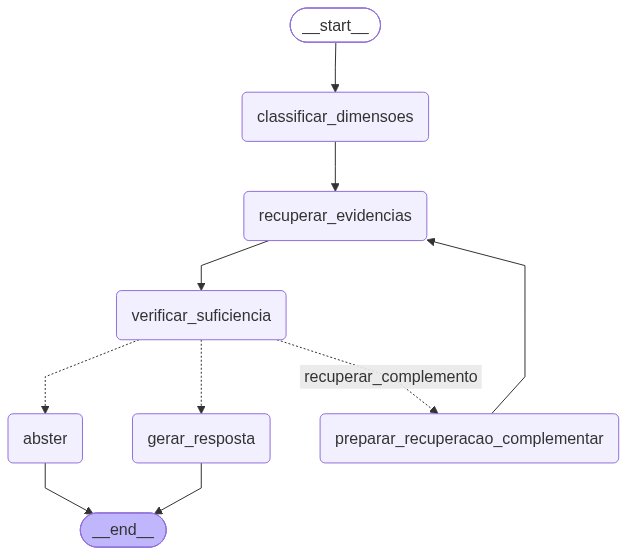

In [243]:
# ============================================================
# VISUALIZAÇÃO DO WORKFLOW
# ============================================================

from IPython.display import (
    Image,
    display,
)


display(
    Image(
        workflow_v2
        .get_graph()
        .draw_mermaid_png()
    )
)

# D. Contexto e memória

## D.1 Contexto e memória de curto prazo

A primeira versão do workflow trata cada pergunta de forma independente. Esse comportamento é adequado para consultas isoladas, mas apresenta uma limitação quando o usuário realiza perguntas encadeadas que dependem de informações estabelecidas em uma interação anterior.

Por exemplo, após identificar um elemento epidemiológico em uma primeira pergunta, o usuário pode realizar uma segunda consulta utilizando expressões referenciais como “esse resultado”, “essa dimensão”, “ele” ou “nesse caso”. Sem contexto conversacional, essas referências podem ser ambíguas.

Para demonstrar essa limitação, inicialmente é executada uma sequência de perguntas sem memória persistente. Em seguida, a v2 é estendida com memória de curto prazo associada a uma conversa.

A memória não é utilizada para substituir as evidências documentais. Sua função é exclusivamente preservar o contexto necessário para interpretar perguntas subsequentes. As respostas epidemiológicas continuam sendo produzidas a partir dos documentos semânticos recuperados.

A persistência é realizada por meio de checkpoints do LangGraph. Cada conversa recebe um identificador (`thread_id`), permitindo que o estado seja recuperado em chamadas posteriores e mantendo isolamento entre conversas distintas.


Essa distinção é muito importante para o trabalho:

memória = contexto da conversa; documentos semânticos = fonte factual.

Não queremos que o agente passe a tratar uma resposta anterior do LLM como fonte epidemiológica.


1. Primeiro demonstre o problema sem memória

Sugiro usarmos uma pergunta realmente dependente da interação anterior:

In [244]:
pergunta_1 = (
    "Qual foi o sinal clínico mais frequente?"
)

pergunta_2 = (
    "Agora compare esse resultado com "
    "a doença preexistente mais frequente."
)

A primeira estabelece que estamos falando de:

Febre — 88,21%

A segunda contém a expressão:

esse resultado

Sem memória, o workflow recebe apenas a segunda frase.

Iremos executar:

In [245]:
# ============================================================
# TESTE SEM MEMÓRIA
# ============================================================

resposta_sem_memoria_1, metricas_sem_memoria_1, _ = (
    executar_v2(
        pergunta_1
    )
)


resposta_sem_memoria_2, metricas_sem_memoria_2, _ = (
    executar_v2(
        pergunta_2
    )
)


print(
    "PRIMEIRA PERGUNTA:"
)

print(
    pergunta_1
)

print(
    "\nRESPOSTA:"
)

print(
    resposta_sem_memoria_1
)


print(
    "\n--------------------------------"
)


print(
    "\nSEGUNDA PERGUNTA:"
)

print(
    pergunta_2
)

print(
    "\nRESPOSTA SEM MEMÓRIA:"
)

print(
    resposta_sem_memoria_2
)

PRIMEIRA PERGUNTA:
Qual foi o sinal clínico mais frequente?

RESPOSTA:
answer='O sinal clínico mais frequente foi Febre (88,21% dos registros avaliáveis).' evidence=['- **Variavel:** FEBRE_DECODED | **Sinal clinico:** Febre | **Total registros:** 444.266 | **Avaliaveis:** 428.673 | **Sim:** 378.134 | **Nao:** 50.539 | **Ausentes:** 15.593 | **Percentual sim:** 88,21% | **Percentual ausentes:** 3,51%', '- **Indicadores**: **Sinal clinico maior frequencia:** Febre | **Percentual sinal clinico:** 88,21%'] document_id='sinan_dengue_2026_clinico_brasil' confidence='alta' insufficient_information=False

--------------------------------

SEGUNDA PERGUNTA:
Agora compare esse resultado com a doença preexistente mais frequente.

RESPOSTA SEM MEMÓRIA:
answer='As evidências disponíveis não são suficientes para responder à pergunta com segurança.' evidence=[] document_id='sinan_dengue_2026_clinico_brasil.md; sinan_dengue_2026_panorama_geral.md; sinan_dengue_2026_temporal_brasil.md; sinan_dengue_202

Aqui precisamos observar o resultado real, e não afirmar antecipadamente que ele necessariamente falhará.

O modelo pode:

perceber que “esse resultado” está sem referente;
fazer uma interpretação parcial;
ou até acertar por coincidência devido ao conteúdo do documento clínico.

Para o relatório, o importante é registrar exatamente o comportamento observado.

D.2 — Acrescentar memória ao estado

Precisamos agora armazenar um pequeno histórico conversacional.

Iremos acrescentar ao AgentState:
```
    # --------------------------------------------------------
    # Memória conversacional
    # --------------------------------------------------------

    historico_conversa: List[Dict]

    contexto_anterior: Optional[str]
```
Entretanto, para a versão com checkpoint não vamos criar um estado totalmente novo a cada turno. O checkpoint será responsável pela persistência.    

D.3 — Nó para preparar um novo turno

Precisamos evitar que evidências da pergunta anterior permaneçam como se fossem evidências da pergunta atual.

Criaremos:

In [246]:
# ============================================================
# NÓ: PREPARAR NOVO TURNO
# ============================================================

def preparar_turno(
    state: AgentState
) -> AgentState:

    historico = list(
        state.get(
            "historico_conversa",
            []
        )
    )

    # --------------------------------------------------------
    # Construir contexto curto a partir do histórico
    # --------------------------------------------------------

    if historico:

        contexto_anterior = "\n\n".join(
            [
                (
                    f"Pergunta anterior: "
                    f"{item['pergunta']}\n"
                    f"Resposta anterior: "
                    f"{item['resposta']}"
                )
                for item
                in historico[-3:]
            ]
        )

    else:

        contexto_anterior = None

    # --------------------------------------------------------
    # Limpar somente o estado transitório do novo turno
    # --------------------------------------------------------

    return {
        **state,

        "historico_conversa":
            historico,

        "contexto_anterior":
            contexto_anterior,

        "dimensoes":
            [],

        "plano_recuperacao":
            [],

        "evidencias":
            [],

        "documentos_consultados":
            [],

        "evidencia_suficiente":
            False,

        "justificativa_suficiencia":
            None,

        "dimensoes_faltantes":
            [],

        "resposta_final":
            None,

        "chamadas_llm":
            0,

        "chamadas_ferramentas":
            0,

        "passos":
            1,

        "erro":
            None,
    }

Essa versão fica conceitualmente mais clara:
```
finalizar_turno
    ↓
salva pergunta + resposta no histórico
    ↓
checkpoint

próxima pergunta
    ↓
preparar_turno
    ↓
lê histórico
    ↓
monta contexto_anterior

D.4 — Usar o contexto na classificação

Agora fazemos uma pequena alteração em classificar_dimensoes().

Atualmente possuimos:
```
HumanMessage(
    content=pergunta
)

D.5 — Usar o contexto também na geração

D.6 — Registrar o turno concluído

Precisamos guardar qual foi a pergunta que acabou de ser respondida.

Criamos:

In [247]:
# ============================================================
# NÓ: FINALIZAR TURNO
# ============================================================

def finalizar_turno(
    state: AgentState
) -> AgentState:

    historico = list(
        state.get(
            "historico_conversa",
            []
        )
    )

    resposta = (
        state.get(
            "resposta_final"
        )
    )

    if resposta is not None:

        historico.append(
            {
                "pergunta":
                    state["pergunta"],

                "resposta":
                    resposta.answer,
            }
        )

    # Limita o histórico persistido
    historico = historico[-3:]

    return {
        **state,

        "historico_conversa":
            historico,

        "pergunta_anterior":
            state["pergunta"],

        "passos":
            state["passos"]
            + 1,
    }

Agora o final do grafo muda de:
```
gerar_resposta → END
abster → END

para:

gerar_resposta
       ↓
finalizar_turno
       ↓
      END

e:

abster
   ↓
finalizar_turno
   ↓
  END

D.7 — Criar o grafo com memória

Usamos o InMemorySaver, que o LangGraph atualmente recomenda para demonstrações/testes de memória de curto prazo; em produção normalmente se utiliza um backend persistente.


In [248]:
## ============================================================
# CHECKPOINTER
# ============================================================

from langgraph.checkpoint.memory import (
    InMemorySaver,
)


checkpointer_v2 = (
    InMemorySaver()
)

Agora criamos um novo builder, em vez de alterar o anterior. Isso preserva claramente:
```
workflow_v2          → sem memória
workflow_v2_memoria  → com memória

In [249]:
# ============================================================
# GRAFO COM MEMÓRIA
# ============================================================

builder_v2_memoria = (
    StateGraph(
        AgentState
    )
)


builder_v2_memoria.add_node(
    "preparar_turno",
    preparar_turno,
)

builder_v2_memoria.add_node(
    "classificar_dimensoes",
    classificar_dimensoes,
)

builder_v2_memoria.add_node(
    "recuperar_evidencias",
    recuperar_evidencias,
)

builder_v2_memoria.add_node(
    "verificar_suficiencia",
    verificar_suficiencia,
)

builder_v2_memoria.add_node(
    "preparar_recuperacao_complementar",
    preparar_recuperacao_complementar,
)

builder_v2_memoria.add_node(
    "gerar_resposta",
    gerar_resposta,
)

builder_v2_memoria.add_node(
    "abster",
    abster_resposta,
)

builder_v2_memoria.add_node(
    "finalizar_turno",
    finalizar_turno,
)

Conectamos

In [250]:
# ============================================================
# FLUXO
# ============================================================

builder_v2_memoria.add_edge(
    START,
    "preparar_turno",
)

builder_v2_memoria.add_edge(
    "preparar_turno",
    "classificar_dimensoes",
)

builder_v2_memoria.add_edge(
    "classificar_dimensoes",
    "recuperar_evidencias",
)

builder_v2_memoria.add_edge(
    "recuperar_evidencias",
    "verificar_suficiencia",
)

Roteamento:

In [251]:
builder_v2_memoria.add_conditional_edges(
    "verificar_suficiencia",

    decidir_apos_suficiencia,

    {
        "gerar_resposta":
            "gerar_resposta",

        "recuperar_complemento":
            "preparar_recuperacao_complementar",

        "abster":
            "abster",
    },
)

Loop complementar:

In [252]:
builder_v2_memoria.add_edge(
    "preparar_recuperacao_complementar",
    "recuperar_evidencias",
)

Finais:

In [253]:
builder_v2_memoria.add_edge(
    "gerar_resposta",
    "finalizar_turno",
)

builder_v2_memoria.add_edge(
    "abster",
    "finalizar_turno",
)

builder_v2_memoria.add_edge(
    "finalizar_turno",
    END,
)

E compilamos com o checkpointer:

In [254]:
workflow_v2_memoria = (
    builder_v2_memoria.compile(
        checkpointer=checkpointer_v2
    )
)

O checkpoint associado a um thread_id é justamente o mecanismo que permite ao LangGraph recuperar estado entre chamadas da mesma conversa.

D.8 — Função de execução conversacional

Agora há uma diferença importante.

Nas chamadas seguintes, não devemos reinicializar todo o estado.

Criamos:

In [255]:
# ============================================================
# EXECUTAR TURNO COM MEMÓRIA
# ============================================================

def executar_turno_memoria(
    pergunta: str,
    thread_id: str,
):

    config = {
        "configurable": {
            "thread_id":
                thread_id
        },

        "recursion_limit":
            MAX_PASSOS + 5,
    }


    resultado = (
        workflow_v2_memoria.invoke(
            {
                "pergunta":
                    pergunta
            },

            config=config,
        )
    )


    return resultado

Esse thread_id é fundamental.

A documentação atual define a memória curta como persistência em nível de thread, permitindo continuidade da mesma conversa e separação de conversas distintas.

D.9 — Teste com memória

Agora executamos:

In [256]:
# ============================================================
# CONVERSA COM MEMÓRIA
# ============================================================

THREAD_TESTE = (
    "conversa_epidemiologica_openai_01"
)

Primeiro turno:

In [257]:
resultado_turno_1 = (
    executar_turno_memoria(
        pergunta=(
            "Qual foi o sinal clínico "
            "mais frequente?"
        ),

        thread_id=THREAD_TESTE,
    )
)


print(
    resultado_turno_1[
        "resposta_final"
    ]
)

answer='O sinal clínico mais frequente foi Febre, presente em 88,21% dos registros avaliáveis.' evidence=['**Variavel:** FEBRE_DECODED | **Sinal clinico:** Febre | **Total registros:** 444.266 | **Avaliaveis:** 428.673 | **Sim:** 378.134 | **Nao:** 50.539 | **Ausentes:** 15.593 | **Percentual sim:** 88,21% | **Percentual ausentes:** 3,51%', '**Indicadores**: **Sinal clinico maior frequencia:** Febre | **Percentual sinal clinico:** 88,21%'] document_id='sinan_dengue_2026_clinico_brasil' confidence='alta' insufficient_information=False


Depois:

In [258]:
LOG_FERRAMENTAS_V2.clear()

In [259]:
resultado_turno_2 = (
    executar_turno_memoria(
        pergunta=(
            "Agora compare esse resultado "
            "com a doença preexistente "
            "mais frequente."
        ),

        thread_id=THREAD_TESTE,
    )
)


print(
    resultado_turno_2[
        "resposta_final"
    ]
)

answer='O sinal clínico mais frequente (Febre: 88,21% dos registros avaliáveis) é muito mais prevalente que a doença preexistente mais frequente (Hipertensão arterial: 7,74% dos registros avaliáveis).' evidence=['No Brasil, foram considerados 444,266 registros de dengue entre as semanas epidemiológicas 1 e 34 de 2026.', 'Entre os sinais clínicos avaliados, Febre apresentou a maior frequência de respostas positivas, com 88.21% dos registros avaliáveis para essa variável.', 'Variavel: HIPERTENSA_DECODED | Doenca preexistente: Hipertensão arterial | Total registros: 444.266 | Avaliaveis: 428.667 | Sim: 33.179 | Nao: 395.488 | Ausentes: 15.599 | Percentual sim: 7,74% | Percentual ausentes: 3,51%'] document_id='sinan_dengue_2026_clinico_brasil' confidence='alta' insufficient_information=False


In [260]:
print(
    "RESPOSTA FINAL:"
)

print(
    resultado_turno_2[
        "resposta_final"
    ]
)


print(
    "\nCONTEXTO ANTERIOR:"
)

print(
    resultado_turno_2.get(
        "contexto_anterior"
    )
)


print(
    "\nDIMENSÕES:"
)

print(
    resultado_turno_2.get(
        "dimensoes"
    )
)


print(
    "\nDOCUMENTOS CONSULTADOS:"
)

print(
    resultado_turno_2.get(
        "documentos_consultados"
    )
)


print(
    "\nSEÇÕES RECUPERADAS:"
)

for item in LOG_FERRAMENTAS_V2:

    print(
        item.get(
            "secoes_retornadas"
        )
    )


print(
    "\nEVIDÊNCIA SUFICIENTE:"
)

print(
    resultado_turno_2.get(
        "evidencia_suficiente"
    )
)


print(
    "\nJUSTIFICATIVA:"
)

print(
    resultado_turno_2.get(
        "justificativa_suficiencia"
    )
)


print(
    "\nERRO:"
)

print(
    resultado_turno_2.get(
        "erro"
    )
)

RESPOSTA FINAL:
answer='O sinal clínico mais frequente (Febre: 88,21% dos registros avaliáveis) é muito mais prevalente que a doença preexistente mais frequente (Hipertensão arterial: 7,74% dos registros avaliáveis).' evidence=['No Brasil, foram considerados 444,266 registros de dengue entre as semanas epidemiológicas 1 e 34 de 2026.', 'Entre os sinais clínicos avaliados, Febre apresentou a maior frequência de respostas positivas, com 88.21% dos registros avaliáveis para essa variável.', 'Variavel: HIPERTENSA_DECODED | Doenca preexistente: Hipertensão arterial | Total registros: 444.266 | Avaliaveis: 428.667 | Sim: 33.179 | Nao: 395.488 | Ausentes: 15.599 | Percentual sim: 7,74% | Percentual ausentes: 3,51%'] document_id='sinan_dengue_2026_clinico_brasil' confidence='alta' insufficient_information=False

CONTEXTO ANTERIOR:
Pergunta anterior: Qual foi o sinal clínico mais frequente?
Resposta anterior: O sinal clínico mais frequente foi Febre, presente em 88,21% dos registros avaliáveis.

Também mostre a memória:

In [261]:
print(
    "\nCONTEXTO UTILIZADO:"
)

print(
    resultado_turno_2[
        "contexto_anterior"
    ]
)


CONTEXTO UTILIZADO:
Pergunta anterior: Qual foi o sinal clínico mais frequente?
Resposta anterior: O sinal clínico mais frequente foi Febre, presente em 88,21% dos registros avaliáveis.


Queremos ver algo conceitualmente semelhante a:

Pergunta anterior:
Qual foi o sinal clínico mais frequente?

Resposta anterior:
O sinal clínico mais frequente foi Febre (88,21%).

E a segunda resposta deverá comparar isso com a informação do documento clínico sobre:

Hipertensão arterial (7,74%)

E:

insufficient_information=False

Se isso acontecer, teremos demonstrado exatamente o que precisamos para a Seção D:
```
SEM MEMÓRIA
"Agora compare esse resultado..."
        ↓
referência não resolvida
        ↓
abstenção

COM MEMÓRIA
"Agora compare esse resultado..."
        ↓
recupera pergunta/resposta anterior
        ↓
"esse resultado" = Febre
        ↓
recupera documento clínico
        ↓
resposta fundamentada

### D.11 Resultado da demonstração de memória

No experimento sem memória, a segunda pergunta utilizou a expressão referencial “esse resultado” sem que o workflow tivesse acesso ao turno anterior, resultando em informação insuficiente para produzir uma resposta fundamentada.

Após a inclusão do mecanismo de checkpoint e da memória de curto prazo, a mesma sequência foi executada utilizando um `thread_id` comum. O segundo turno recuperou corretamente o contexto da interação anterior, identificando que “esse resultado” se referia ao sinal clínico Febre.

Com o contexto resolvido, o workflow recuperou novamente o documento clínico e produziu uma resposta fundamentada nas evidências documentais, comparando Febre (88,21%) com Hipertensão arterial (7,74%).

O experimento mostra que a memória não substitui a recuperação documental. O histórico é utilizado para resolver referências conversacionais, enquanto os fatos epidemiológicos permanecem fundamentados nos documentos semânticos recuperados pelo workflow.


### D.12 Isolamento entre conversas

Além da continuidade dentro de uma mesma conversa, o mecanismo de memória deve garantir o isolamento entre conversas distintas.

Para verificar esse comportamento, uma nova execução é iniciada utilizando um `thread_id` diferente daquele empregado no teste anterior.

A nova conversa recebe diretamente uma pergunta contendo a expressão “esse resultado”, sem que tenha ocorrido uma interação anterior nesse mesmo thread.

O comportamento esperado é que o contexto da conversa anterior não seja reutilizado. Dessa forma, informações persistidas em um thread não devem interferir na interpretação de perguntas pertencentes a outro thread.


In [262]:
# ============================================================
# TESTE DE ISOLAMENTO ENTRE THREADS
# ============================================================

THREAD_ISOLADO = (
    "conversa_epidemiologica_isolada"
)


resultado_isolado = (
    executar_turno_memoria(
        pergunta=(
            "Agora compare esse resultado "
            "com a doença preexistente "
            "mais frequente."
        ),

        thread_id=THREAD_ISOLADO,
    )
)


print(
    "CONTEXTO DA NOVA CONVERSA:"
)

print(
    resultado_isolado[
        "contexto_anterior"
    ]
)


print(
    "\nRESPOSTA:"
)

print(
    resultado_isolado[
        "resposta_final"
    ]
)

CONTEXTO DA NOVA CONVERSA:
None

RESPOSTA:
answer='As evidências disponíveis não são suficientes para responder à pergunta com segurança.' evidence=[] document_id='sinan_dengue_2026_clinico_brasil.md; sinan_dengue_2026_panorama_geral.md; sinan_dengue_2026_desfechos_brasil.md; sinan_dengue_2026_obitos_brasil.md; sinan_dengue_2026_temporal_brasil.md; sinan_dengue_2026_geografico_brasil.md; sinan_dengue_2026_sorotipos_brasil.md' confidence='baixa' insufficient_information=True


O resultado fundamental esperado é:

CONTEXTO DA NOVA CONVERSA:
None

### D.13 Resultado do teste de isolamento

O teste com um novo `thread_id` não recuperou o histórico da conversa anterior. O campo `contexto_anterior` permaneceu vazio no primeiro turno da nova conversa, confirmando que os checkpoints são associados a conversas específicas.

Esse comportamento evita que o contexto de uma interação seja utilizado indevidamente em outra conversa e demonstra o isolamento da memória de curto prazo implementada na v2.


# E. Ferramentas e integração externa



## E.1 Integração externa utilizada

A capacidade externa da v2 é o acesso controlado à coleção de documentos semânticos epidemiológicos produzidos pelo pipeline do SINAN e armazenados como arquivos Markdown no ambiente de execução.

A integração foi implementada como **Tool local LangChain**. A ferramenta recebe a pergunta e as dimensões epidemiológicas autorizadas, acessa apenas os caminhos definidos no catálogo da aplicação e retorna seções Markdown compactas selecionadas por relevância lexical.

Os retornos da ferramenta são tratados como conteúdo externo não confiável: eles fornecem evidências ao workflow, mas não alteram as instruções do sistema. A Tool possui apenas privilégio de leitura e não aceita caminhos arbitrários.

## E.2 Implementação e auditoria da Tool

A Tool `ferramenta_documentos_semanticos` foi definida anteriormente porque é utilizada diretamente pelo nó `recuperar_evidencias()` durante a construção do workflow.

Cada chamada registra:

- pergunta recebida;
- dimensões válidas;
- documentos retornados;
- seções selecionadas;
- quantidade de caracteres recuperados.

Essa instrumentação permite auditar a seleção das evidências e quantificar a redução do contexto em relação aos documentos completos.

O contrato de integração preenchido é apresentado ao final desta seção.


E.3 — Testar a tool diretamente

Antes de colocar no grafo:

In [263]:
LOG_FERRAMENTAS_V2.clear()


resultado_tool = (
    ferramenta_documentos_semanticos.invoke(
        {
            "pergunta":
                "Qual foi o sinal clínico mais frequente "
                "e quais sorotipos foram registrados?",

            "dimensoes": [
                "clinica",
                "virologica",
            ],
        }
    )
)


print(
    "Documentos recuperados:"
)


for documento in resultado_tool:

    print(
        "-",
        documento["arquivo"]
    )


print(
    "\nLOG:"
)

print(
    LOG_FERRAMENTAS_V2
)

Documentos recuperados:
- sinan_dengue_2026_clinico_brasil.md
- sinan_dengue_2026_sorotipos_brasil.md

LOG:
[{'tool': 'ferramenta_documentos_semanticos', 'argumentos': {'pergunta': 'Qual foi o sinal clínico mais frequente e quais sorotipos foram registrados?', 'dimensoes': ['clinica', 'virologica']}, 'documentos_retornados': ['sinan_dengue_2026_clinico_brasil.md', 'sinan_dengue_2026_sorotipos_brasil.md'], 'secoes_retornadas': {'sinan_dengue_2026_clinico_brasil.md': ['Sinais clinicos', 'Indicadores'], 'sinan_dengue_2026_sorotipos_brasil.md': ['Distribuicao nacional sorotipos', 'Síntese epidemiológica']}, 'caracteres_recuperados': 3061}]


Esperamos recuperar os documentos clínico e virológico, além de algo como:
```
[
    {
        'tool': 'ferramenta_documentos_semanticos',
        'argumentos': {
            'dimensoes': [
                'clinica',
                'virologica'
            ]
        },
        'documentos_retornados': [
            'sinan_dengue_2026_clinico_brasil.md',
            'sinan_dengue_2026_sorotipos_brasil.md'
        ]
    }
]
```
Isso demonstra:
```
Tool
 ├── nome
 ├── argumentos
 ├── validação
 ├── execução real
 ├── retorno
 └── log
```

### E.4 Uso efetivo da Tool no workflow

A Tool não é apenas demonstrativa. O nó `recuperar_evidencias()` a utiliza diretamente:

```python
documentos = ferramenta_documentos_semanticos.invoke(
    {
        "pergunta": state["pergunta"],
        "dimensoes": dimensoes,
    }
)
```

O fluxo real da recuperação é:

```text
LangGraph
   ↓
recuperar_evidencias
   ↓
ferramenta_documentos_semanticos
   ↓
recuperar_documentos_semanticos_compacto
   ↓
dividir_markdown_em_secoes
   ↓
selecionar_secoes_relevantes
   ↓
trechos Markdown compactos
```

Assim, a ferramenta faz parte efetiva da execução e preserva rastreabilidade até os arquivos e seções de origem.


E.5 — Teste de menor privilégio

Também vale mostrar que uma dimensão inválida não dá acesso arbitrário ao sistema.

In [264]:
# ============================================================
# TESTE DE ARGUMENTO NÃO PERMITIDO
# ============================================================

resultado_invalido = (
    ferramenta_documentos_semanticos.invoke(
        {
            "pergunta":
                "Qual foi o sinal clínico mais frequente?",

            "dimensoes": [
                "clinica",
                "senhas",
                "../../../",
            ],
        }
    )
)


print(
    "Documentos recuperados:"
)


for documento in resultado_invalido:

    print(
        "-",
        documento["arquivo"]
    )

Documentos recuperados:
- sinan_dengue_2026_clinico_brasil.md


Apenas:

sinan_dengue_2026_clinico_brasil.md

deve ser considerado.

Não estamos tentando realizar um ataque; estamos simplesmente demonstrando que a interface trabalha com uma allowlist semântica, e não com caminhos arbitrários.

### E.6 Decisão sobre MCP

A integração foi implementada como ferramenta local e não como servidor MCP.

Nesta versão, a coleção de documentos é utilizada por um único workflow executado no notebook e os arquivos estão disponíveis diretamente no ambiente de execução. A introdução de um servidor MCP acrescentaria complexidade operacional sem resolver uma limitação observada no baseline.

MCP passa a ser uma alternativa arquitetural relevante caso a capacidade de recuperação dos documentos semânticos precise ser reutilizada por múltiplos agentes, aplicações ou workflows independentes. Nesse cenário, a recuperação poderia ser exposta como um serviço padronizado, desacoplando o acesso à coleção de documentos da implementação específica deste agente.

Portanto, para a v2, a ferramenta local foi considerada suficiente e mais proporcional ao problema experimental.


E.7 — Preencher contrato_integracao

O template já possui essa variável.

In [265]:
# ============================================================
# CONTRATO DA INTEGRAÇÃO
# ============================================================

contrato_integracao = {

    "capacidade":
        (
            "Recuperação compacta de evidências "
            "em seções de documentos semânticos "
            "epidemiológicos, orientada pela pergunta "
            "e pelas dimensões identificadas."
        ),

    "implementacao":
        "tool local LangChain",

    "tools": [
        "ferramenta_documentos_semanticos"
    ],

    "resources": [
        (
            "Seções selecionadas de documentos Markdown "
            "produzidos pelo pipeline SINAN 2026."
        )
    ],

    "argumentos_permitidos":
        DIMENSOES_SUPORTADAS,

    "acesso_arbitrario_arquivos":
        False,

    "registro_chamadas":
        True,

    "retorno_tratado_como":
        "conteúdo externo não confiável",

    "mcp_utilizado":
        False,

    "justificativa_mcp":
        (
            "A capacidade é utilizada apenas pelo "
            "workflow local. MCP seria considerado "
            "caso a recuperação precisasse ser "
            "compartilhada entre múltiplos agentes "
            "ou aplicações."
        ),
}


contrato_integracao

{'capacidade': 'Recuperação compacta de evidências em seções de documentos semânticos epidemiológicos, orientada pela pergunta e pelas dimensões identificadas.',
 'implementacao': 'tool local LangChain',
 'tools': ['ferramenta_documentos_semanticos'],
 'resources': ['Seções selecionadas de documentos Markdown produzidos pelo pipeline SINAN 2026.'],
 'argumentos_permitidos': ['geral',
  'temporal',
  'geografica',
  'clinica',
  'virologica',
  'desfechos'],
 'acesso_arbitrario_arquivos': False,
 'registro_chamadas': True,
 'retorno_tratado_como': 'conteúdo externo não confiável',
 'mcp_utilizado': False,
 'justificativa_mcp': 'A capacidade é utilizada apenas pelo workflow local. MCP seria considerado caso a recuperação precisasse ser compartilhada entre múltiplos agentes ou aplicações.'}

# F. Comparação v1 × v2


## F.1 Estratégia de comparação entre v1 e v2

A comparação entre as duas versões utiliza os mesmos casos de teste definidos no Entregável 1.

Os casos T01–T10 permanecem congelados e são executados nas duas arquiteturas sob as mesmas condições de modelo, temperatura, formato de saída e critérios de verificação.

A diferença experimental está exclusivamente na arquitetura de execução.

Na v1, o modelo recebe diretamente um único documento integrado previamente selecionado.

Na v2, o sistema classifica as dimensões da pergunta, recupera os documentos semânticos relevantes, verifica a suficiência das evidências e então gera a resposta.

A comparação considera:

* correção das respostas;
* cobertura dos elementos esperados;
* abstenção em casos de informação ausente;
* presença de evidências;
* rastreabilidade;
* latência aproximada;
* número de chamadas ao LLM;
* número de chamadas de ferramentas;
* número de passos do workflow;
* novos modos de falha introduzidos pela arquitetura v2.

O caso T09 permanece sujeito à avaliação manual segundo a mesma rubrica utilizada no baseline.

Devido ao pequeno número de casos e à execução limitada, diferenças de latência devem ser interpretadas apenas como indicativas e não como evidência conclusiva de desempenho.


Agora vamos criar uma função para executar os T01–T10 na v2.

In [266]:
#
# Fazer as comparações e guardá-las em "v2_resultados.json", igual vimos nos notebooks das aulas.
#
# ============================================================
# EXECUÇÃO DOS CASOS CONGELADOS NA V2
# ============================================================

import pandas as pd
import time


def executar_experimento_v2(
    casos
):

    registros = []

    for caso in casos:

        print(
            f"Executando {caso['id']}..."
        )

        inicio = time.perf_counter()

        try:

            resposta, metricas, estado = (
                executar_v2(
                    caso["pergunta"]
                )
            )

            latencia_total = (
                time.perf_counter()
                -
                inicio
            )

            verificacao = (
                verificar_caso(
                    caso,
                    resposta
                )
            )

            rastreabilidade_ok = (
                bool(
                    resposta.document_id
                )
            )

            registro = {

                "id":
                    caso["id"],

                "dimensao":
                    caso["dimensao"],

                "tipo":
                    caso["tipo"],

                "pergunta":
                    caso["pergunta"],

                "resposta":
                    resposta.answer,

                "esperado":
                    caso["esperado"],

                "evidencias":
                    resposta.evidence,

                "documento":
                    resposta.document_id,

                "confianca":
                    resposta.confidence,

                "informacao_insuficiente":
                    resposta.insufficient_information,

                "avaliacao":
                    verificacao[
                        "avaliacao"
                    ],

                "cobertura":
                    verificacao[
                        "cobertura"
                    ],

                "aprovado":
                    verificacao[
                        "aprovado"
                    ],

                "possui_evidencias":
                    verificacao[
                        "possui_evidencias"
                    ],

                "abstencao_correta":
                    verificacao[
                        "abstencao_correta"
                    ],

                "rastreabilidade_ok":
                    rastreabilidade_ok,

                "latencia_s":
                    round(
                        latencia_total,
                        3
                    ),

                "chamadas_llm":
                    metricas[
                        "chamadas_llm"
                    ],

                "chamadas_ferramentas":
                    metricas[
                        "chamadas_ferramentas"
                    ],

                "passos":
                    metricas[
                        "passos"
                    ],

                "dimensoes_detectadas":
                    metricas[
                        "dimensoes"
                    ],

                "documentos_consultados":
                    metricas[
                        "documentos_consultados"
                    ],

                "evidencia_suficiente":
                    metricas[
                        "evidencia_suficiente"
                    ],

                "erro":
                    metricas[
                        "erro"
                    ],
            }


        except Exception as e:

            registro = {

                "id":
                    caso["id"],

                "dimensao":
                    caso["dimensao"],

                "tipo":
                    caso["tipo"],

                "pergunta":
                    caso["pergunta"],

                "resposta":
                    None,

                "esperado":
                    caso["esperado"],

                "evidencias":
                    None,

                "documento":
                    None,

                "confianca":
                    None,

                "informacao_insuficiente":
                    None,

                "avaliacao":
                    caso[
                        "verificacao"
                    ],

                "cobertura":
                    None,

                "aprovado":
                    False,

                "possui_evidencias":
                    False,

                "abstencao_correta":
                    None,

                "rastreabilidade_ok":
                    False,

                "latencia_s":
                    round(
                        time.perf_counter()
                        -
                        inicio,
                        3
                    ),

                "chamadas_llm":
                    None,

                "chamadas_ferramentas":
                    None,

                "passos":
                    None,

                "dimensoes_detectadas":
                    None,

                "documentos_consultados":
                    None,

                "evidencia_suficiente":
                    None,

                "erro":
                    str(e),
            }


        registros.append(
            registro
        )

    return pd.DataFrame(
        registros
    )

In [341]:
# ============================================================
# RODAR T01-T10 NA V2
# ============================================================

df_v2 = (
    executar_experimento_v2(
        test_cases
    )
)


display(
    df_v2[
        [
            "id",
            "dimensao",
            "tipo",
            "aprovado",
            "cobertura",
            "informacao_insuficiente",
            "rastreabilidade_ok",
            "chamadas_llm",
            "chamadas_ferramentas",
            "passos",
            "latencia_s",
        ]
    ]
)

Executando T01...
Executando T02...
Executando T03...
Executando T04...
Executando T05...
Executando T06...
Executando T07...
Executando T08...
Executando T09...
Executando T10...


,id,dimensao,tipo,aprovado,cobertura,informacao_insuficiente,rastreabilidade_ok,chamadas_llm,chamadas_ferramentas,passos,latencia_s
0,T01,geral,normal,True,1.0,False,True,3,1,4,20.753
1,T02,temporal,normal,True,1.0,False,True,3,1,4,13.382
2,T03,geografica,normal,True,1.0,False,True,3,1,4,18.569
3,T04,geografica,normal,True,1.0,False,True,3,1,4,15.825
4,T05,virologica,normal,True,1.0,False,True,3,1,4,15.764
5,T06,clinica,normal,True,1.0,False,True,3,1,4,17.656
6,T07,desfechos,normal,True,1.0,False,True,3,1,4,13.898
7,T08,multidimensional,composto,True,1.0,False,True,3,1,4,38.855
8,T09,qualidade_dados,interpretativo,None,NaN,False,True,3,1,4,22.253
9,T10,fora_escopo,informacao_ausente,True,NaN,True,True,3,2,7,19.072


Para T09, aplique a mesma avaliação manual usada na v1:

In [342]:
# ============================================================
# AVALIAÇÃO MANUAL T09 - V2
# ============================================================

linha_t09_v2 = (
    df_v2[
        df_v2["id"] == "T09"
    ]
    .iloc[0]
)


print(
    linha_t09_v2[
        "resposta"
    ]
)

A principal limitação é a alta proporção de registros sem informação de sorotipo e a heterogeneidade na completude por Unidade Federativa. Especificamente: 414.749 registros (93,36%) não possuem sorotipo informado, a distribuição nacional considera apenas os registros com sorotipo disponível, diferenças entre UFs devem ser interpretadas considerando essa disponibilidade, e há UFs sem nenhum registro de sorotipo (ex.: Amapá). Além disso, os resultados referem‑se apenas às semanas epidemiológicas 1 a 34 de 2026.


Depois avaliamos:

In [343]:
avaliacao_manual_t09_v2 = {

    "identifica_baixa_disponibilidade_sorotipo":
        True,

    "usa_evidencia_do_documento":
        True,

    "nao_introduz_informacao_externa":
        True,
}


pontuacao_t09_v2 = (
    sum(
        avaliacao_manual_t09_v2.values()
    )
)


aprovado_t09_v2 = (
    pontuacao_t09_v2 >= 2
)


df_v2.loc[
    df_v2["id"] == "T09",
    "aprovado"
] = aprovado_t09_v2


df_v2.loc[
    df_v2["id"] == "T09",
    "pontuacao_manual"
] = pontuacao_t09_v2

Ajuste os True/False conforme a resposta real do T09.

Agora geramos um resumo da v2:

In [344]:
# ============================================================
# RESUMO V2
# ============================================================

casos_auto_v2 = (
    df_v2[
        df_v2[
            "avaliacao"
        ] == "automatica"
    ]
)


total_auto_v2 = (
    len(
        casos_auto_v2
    )
)


aprovados_auto_v2 = (
    casos_auto_v2[
        "aprovado"
    ]
    .fillna(False)
    .sum()
)


taxa_auto_v2 = (
    100
    *
    aprovados_auto_v2
    /
    total_auto_v2
)


RESUMO_V2 = {

    "total_casos":
        len(df_v2),

    "casos_avaliacao_automatica":
        total_auto_v2,

    "casos_automaticos_aprovados":
        int(
            aprovados_auto_v2
        ),

    "taxa_aprovacao_automatica_pct":
        round(
            taxa_auto_v2,
            2
        ),

    "casos_avaliacao_manual":
        int(
            (
                df_v2[
                    "avaliacao"
                ]
                ==
                "manual"
            )
            .sum()
        ),

    "latencia_media_s":
        round(
            df_v2[
                "latencia_s"
            ]
            .mean(),
            3
        ),

    "latencia_mediana_s":
        round(
            df_v2[
                "latencia_s"
            ]
            .median(),
            3
        ),

    "respostas_com_evidencias_pct":
        round(
            100
            *
            df_v2[
                "possui_evidencias"
            ]
            .fillna(False)
            .mean(),
            2
        ),

    "rastreabilidade_correta_pct":
        round(
            100
            *
            df_v2[
                "rastreabilidade_ok"
            ]
            .fillna(False)
            .mean(),
            2
        ),

    "total_chamadas_llm":
        int(
            df_v2[
                "chamadas_llm"
            ]
            .fillna(0)
            .sum()
        ),

    "total_chamadas_ferramentas":
        int(
            df_v2[
                "chamadas_ferramentas"
            ]
            .fillna(0)
            .sum()
        ),

    "total_passos":
        int(
            df_v2[
                "passos"
            ]
            .fillna(0)
            .sum()
        ),

    "pontuacao_manual_t09":
        pontuacao_t09_v2,
}


RESUMO_V2

{'total_casos': 10,
 'casos_avaliacao_automatica': 9,
 'casos_automaticos_aprovados': 9,
 'taxa_aprovacao_automatica_pct': 100.0,
 'casos_avaliacao_manual': 1,
 'latencia_media_s': np.float64(19.603),
 'latencia_mediana_s': 18.112,
 'respostas_com_evidencias_pct': np.float64(90.0),
 'rastreabilidade_correta_pct': np.float64(100.0),
 'total_chamadas_llm': 30,
 'total_chamadas_ferramentas': 11,
 'total_passos': 43,
 'pontuacao_manual_t09': 3}

Agora vem a comparação propriamente dita.

In [345]:
# ============================================================
# COMPARAÇÃO V1 x V2
# ============================================================

comparacao_v1_v2 = (
    df_v1[
        [
            "id",
            "aprovado",
            "cobertura",
            "latencia_s",
            "chamadas_llm",
        ]
    ]
    .rename(
        columns={
            "aprovado":
                "aprovado_v1",

            "cobertura":
                "cobertura_v1",

            "latencia_s":
                "latencia_v1_s",

            "chamadas_llm":
                "chamadas_llm_v1",
        }
    )
    .merge(
        df_v2[
            [
                "id",
                "aprovado",
                "cobertura",
                "latencia_s",
                "chamadas_llm",
                "chamadas_ferramentas",
                "passos",
                "dimensoes_detectadas",
                "documentos_consultados",
            ]
        ]
        .rename(
            columns={
                "aprovado":
                    "aprovado_v2",

                "cobertura":
                    "cobertura_v2",

                "latencia_s":
                    "latencia_v2_s",

                "chamadas_llm":
                    "chamadas_llm_v2",
            }
        ),

        on="id",
        how="inner",
    )
)


display(
    comparacao_v1_v2
)

,id,aprovado_v1,cobertura_v1,latencia_v1_s,chamadas_llm_v1,aprovado_v2,cobertura_v2,latencia_v2_s,chamadas_llm_v2,chamadas_ferramentas,passos,dimensoes_detectadas,documentos_consultados
0,T01,True,1.0,7.977,1,True,1.0,20.753,3,1,4,[geral],[sinan_dengue_2026_panorama_geral.md]
1,T02,True,1.0,6.189,1,True,1.0,13.382,3,1,4,[temporal],[sinan_dengue_2026_temporal_brasil.md]
2,T03,True,1.0,6.165,1,True,1.0,18.569,3,1,4,[geografica],[sinan_dengue_2026_geografico_brasil.md]
3,T04,True,1.0,4.839,1,True,1.0,15.825,3,1,4,[geografica],[sinan_dengue_2026_geografico_brasil.md]
4,T05,True,1.0,7.070,1,True,1.0,15.764,3,1,4,[virologica],[sinan_dengue_2026_sorotipos_brasil.md]
5,T06,True,1.0,4.911,1,True,1.0,17.656,3,1,4,[clinica],[sinan_dengue_2026_clinico_brasil.md]
6,T07,True,1.0,5.724,1,True,1.0,13.898,3,1,4,[desfechos],"[sinan_dengue_2026_desfechos_brasil.md, sinan_dengue_2026_obitos_brasil.md]"
7,T08,True,1.0,20.039,1,True,1.0,38.855,3,1,4,"[temporal, geografica, clinica]","[sinan_dengue_2026_temporal_brasil.md, sinan_dengue_2026_geografico_brasil.md, sinan_dengue_2026_clinico_brasil.md]"
8,T09,True,NaN,11.263,1,True,NaN,22.253,3,1,4,[virologica],[sinan_dengue_2026_sorotipos_brasil.md]
9,T10,True,NaN,13.442,1,True,NaN,19.072,3,2,7,"[clinica, desfechos, geral]","[sinan_dengue_2026_clinico_brasil.md, sinan_dengue_2026_desfechos_brasil.md, sinan_dengue_2026_obitos_brasil.md, sinan_dengue_2026_panorama_geral.md]"


Agora uma tabela agregada:

In [346]:
# ============================================================
# RESUMO COMPARATIVO
# ============================================================

resumo_comparativo = pd.DataFrame(
    [
        {
            "metrica":
                "Taxa de aprovação automática (%)",

            "v1":
                RESUMO_V1[
                    "taxa_aprovacao_automatica_pct"
                ],

            "v2":
                RESUMO_V2[
                    "taxa_aprovacao_automatica_pct"
                ],
        },

        {
            "metrica":
                "Latência média (s)",

            "v1":
                RESUMO_V1[
                    "latencia_media_s"
                ],

            "v2":
                RESUMO_V2[
                    "latencia_media_s"
                ],
        },

        {
            "metrica":
                "Latência mediana (s)",

            "v1":
                RESUMO_V1[
                    "latencia_mediana_s"
                ],

            "v2":
                RESUMO_V2[
                    "latencia_mediana_s"
                ],
        },

        {
            "metrica":
                "Respostas com evidências (%)",

            "v1":
                RESUMO_V1[
                    "respostas_com_evidencias_pct"
                ],

            "v2":
                RESUMO_V2[
                    "respostas_com_evidencias_pct"
                ],
        },

        {
            "metrica":
                "Rastreabilidade correta (%)",

            "v1":
                RESUMO_V1[
                    "rastreabilidade_correta_pct"
                ],

            "v2":
                RESUMO_V2[
                    "rastreabilidade_correta_pct"
                ],
        },

        {
            "metrica":
                "Total de chamadas LLM",

            "v1":
                RESUMO_V1[
                    "total_chamadas_llm"
                ],

            "v2":
                RESUMO_V2[
                    "total_chamadas_llm"
                ],
        },

        {
            "metrica":
                "Total de chamadas de ferramentas",

            "v1":
                0,

            "v2":
                RESUMO_V2[
                    "total_chamadas_ferramentas"
                ],
        },
    ]
)


display(
    resumo_comparativo
)

,metrica,v1,v2
0,Taxa de aprovação automática (%),100.000,100.000
1,Latência média (s),8.762,19.603
2,Latência mediana (s),6.630,18.112
3,Respostas com evidências (%),100.000,90.000
4,Rastreabilidade correta (%),100.000,100.000
5,Total de chamadas LLM,10.000,30.000
6,Total de chamadas de ferramentas,0.000,11.000


In [348]:
df_v2[
    df_v2["possui_evidencias"] == False
][
    [
        "id",
        "pergunta",
        "resposta",
        "informacao_insuficiente",
        "evidencia_suficiente",
        "aprovado",
    ]
]

,id,pergunta,resposta,informacao_insuficiente,evidencia_suficiente,aprovado
9,T10,Qual medicamento deve ser utilizado para tratar a dengue?,As evidências disponíveis não são suficientes para responder à pergunta com segurança.,True,False,True


E agora salvamos exatamente o arquivo pedido pelo template:

In [349]:
# ============================================================
# SALVAR RESULTADOS V2
# ============================================================

import json


resultado_exportacao_v2 = {

    "resumo_v2":
        RESUMO_V2,

    "comparacao_v1_v2":
        comparacao_v1_v2.to_dict(
            orient="records"
        ),

    "resultados_v2":
        df_v2.to_dict(
            orient="records"
        ),
}


with open(
    "v2_resultados.json",
    "w",
    encoding="utf-8"
) as arquivo:

    json.dump(
        resultado_exportacao_v2,
        arquivo,
        ensure_ascii=False,
        indent=2,
        default=str,
    )


print(
    "Arquivo salvo: v2_resultados.json"
)

Arquivo salvo: v2_resultados.json


### Análise comparativa

Nos dez casos de teste utilizados, a v1 e a v2 alcançaram 100% de aprovação nos casos submetidos à avaliação automática. Portanto, os resultados não demonstram aumento da taxa de acerto da v2 em relação ao baseline para esse conjunto de perguntas. A v1 já apresentava desempenho elevado porque recebia **diretamente** um documento semântico integrado previamente selecionado.

A principal diferença está nas responsabilidades assumidas pelo sistema. Enquanto a v1 realiza essencialmente uma chamada ao LLM sobre um contexto previamente fornecido, **a v2 identifica as dimensões necessárias, recupera documentos semânticos por meio de ferramenta, seleciona evidências, verifica sua suficiência e utiliza roteamento condicional para decidir entre responder, buscar evidências complementares ou abster-se.**

Essa ampliação de autonomia apresentou custo mensurável. A latência média passou de 8,762 s na v1 para 19,603 s na v2, enquanto a mediana passou de 6,630 s para 18,112 s. O total de chamadas ao LLM aumentou de 10 para 30, e a v2 realizou 11 chamadas de ferramentas, contra nenhuma na v1. Assim, os resultados evidenciam um trade-off entre autonomia e custo computacional.

A rastreabilidade permaneceu em 100% nas duas versões. Na v2, 90% das respostas finais apresentaram evidências. Esse valor não representa uma falha adicional: o único caso sem evidências na resposta final foi T10, no qual a pergunta solicitava indicação de medicamento para dengue. Como **essa informação não estava presente nos documentos recuperados**, o sistema classificou corretamente a informação como insuficiente e realizou abstinência. O caso foi, portanto, considerado aprovado.

O caso T08 demonstrou especificamente a capacidade de composição multidimensional da v2. Para produzir o panorama solicitado, o workflow recuperou documentos das dimensões temporal, geográfica e clínica e integrou evidências como o pico na semana epidemiológica 15, a predominância de Goiás nas notificações por UF de residência e Febre como sinal clínico mais frequente.

Os resultados devem ser interpretados com cautela, pois o conjunto experimental contém apenas dez casos. Não se pretende demonstrar superioridade estatística da arquitetura agentiva, mas verificar se as capacidades adicionadas podem ser incorporadas sem perda de correção nos casos congelados e identificar os novos custos e modos de falha introduzidos.


## G — Novos modos de falha introduzidos pela autonomia

A introdução de autonomia na v2 acrescentou capacidades inexistentes no baseline, mas também criou novos pontos de falha. Durante o desenvolvimento e a avaliação, foram observados problemas que não existiam na v1 porque nela o documento relevante era previamente selecionado.

Um primeiro modo de falha ocorreu na **classificação das dimensões epidemiológicas**. Em uma consulta sobre o total de notificações consideradas no Brasil em 2026, o classificador chegou a interpretar a presença do ano como necessidade da dimensão temporal e a palavra “Brasil” como necessidade da dimensão geográfica. O problema foi corrigido tornando explícito que um ano não implica automaticamente análise temporal e que Brasil pode representar apenas o escopo nacional. Também foi adotado o princípio de selecionar somente as dimensões estritamente necessárias.

Um segundo modo de falha foi observado na **seleção e no ranking das evidências**. Na consulta multidimensional T08, o documento geográfico continha a informação correta sobre a UF com maior número de notificações, mas seções metodológicas receberam pontuação superior a seções de síntese e indicadores. O mecanismo de ranking foi ajustado para considerar a estrutura semântica dos documentos e priorizar, em consultas de panorama, seções com indicadores e sínteses relevantes. Um aumento experimental do número de seções recuperadas também introduziu ruído e reduziu o desempenho, indicando que recuperar mais contexto não implica necessariamente recuperar contexto melhor.

Um terceiro problema surgiu na **verificação de suficiência**. Inicialmente, uma pergunta que mencionava o ano de 2026 foi interpretada como exigindo dados das 52 ou 53 semanas do ano. Como os documentos cobriam as semanas epidemiológicas 1 a 34, o agente realizou uma abstinência indevida, embora o total de 444.266 notificações estivesse explicitamente presente. O verificador foi ajustado para distinguir ausência de evidência de delimitação temporal: quando o valor solicitado está presente e sua janela temporal está claramente documentada, a evidência pode ser considerada suficiente, desde que a resposta preserve essa delimitação.

Também foram identificadas limitações na **avaliação automática das respostas**, como equivalências entre “semana epidemiológica 15” e “semana 15” e diferenças de formatação numérica, por exemplo `21.470` e `21,470`. Essas situações não correspondiam a erros factuais do agente, mas a falsos negativos do avaliador textual. A normalização foi, portanto, tornada mais robusta sem introduzir regras específicas para respostas individuais.

Esses episódios mostram que a autonomia transfere parte da complexidade do pré-processamento humano para decisões executadas durante o workflow. A v2 pode selecionar fontes e decidir quando possui informação suficiente, mas erros nessas decisões podem impedir uma resposta correta mesmo quando a evidência necessária existe.

Como mecanismos de contenção, a arquitetura utiliza conjunto fechado de dimensões, allowlist de documentos acessíveis pela ferramenta, limite explícito de passos/recursão, registro das chamadas de ferramentas e seus argumentos, verificação de suficiência antes da geração final, rastreabilidade dos documentos consultados e abstinência quando a informação necessária não é encontrada. As saídas das ferramentas são tratadas como dados não confiáveis e não como instruções para o modelo.


## H — Análise arquitetural e próxima evolução

### Avaliação da hipótese

Os resultados sustentam parcialmente a hipótese proposta. A v2 não aumentou a taxa de aprovação nos casos congelados, pois a v1 já alcançava 100% nos casos avaliados automaticamente. Entretanto, a v2 preservou esse desempenho enquanto incorporou responsabilidades que anteriormente eram externas ao modelo, principalmente classificação da consulta, recuperação automática de documentos, seleção de evidências, verificação de suficiência, roteamento condicional, abstinência e gerenciamento de contexto conversacional.

O ganho obtido deve, portanto, ser interpretado como **ampliação de capacidade e autonomia**, e não simplesmente como aumento de acurácia. Essa ampliação apresentou custos: maior latência e maior quantidade de chamadas ao LLM e às ferramentas. Além disso, surgiram novos modos de falha associados ao roteamento, ranking de evidências e avaliação de suficiência.

### Por que workflow híbrido em vez de ReAct aberto?

Foi adotado um workflow determinístico com decisões semânticas realizadas pelo LLM. Essa arquitetura híbrida foi considerada mais adequada ao domínio porque as etapas principais são conhecidas antecipadamente: classificar a consulta, recuperar evidências, verificar suficiência e gerar a resposta ou realizar abstinência.

Um agente ReAct aberto teria maior liberdade para decidir dinamicamente quais ações executar, mas acrescentaria variabilidade e dificultaria o controle do número de passos, a reprodutibilidade e a rastreabilidade. No contexto epidemiológico, em que as respostas devem permanecer fundamentadas em documentos específicos, optou-se por restringir a autonomia aos pontos em que decisões semânticas são realmente necessárias.

O LangGraph torna o fluxo explícito e permite impor limites de execução. Dessa forma, a autonomia é utilizada para classificação, seleção e avaliação das evidências, enquanto a sequência geral e as condições de término permanecem controladas.

### Memória e isolamento de contexto

A memória foi incorporada somente após demonstrar uma falha concreta sem contexto persistente. Em uma interação isolada, o sistema conseguiu identificar Febre como o sinal clínico mais frequente, mas não conseguiu interpretar corretamente uma pergunta posterior que utilizava a expressão referencial “esse resultado”. Com checkpoint e `thread_id`, a segunda interação passou a utilizar o contexto anterior para resolver a referência e comparar Febre (88,21%) com Hipertensão arterial (7,74%).

O contexto conversacional é utilizado apenas para resolução de referências e continuidade da interação. Ele não é considerado nova evidência epidemiológica; os fatos apresentados na resposta continuam dependendo dos documentos recuperados. Um `thread_id` diferente não recebe o contexto da conversa anterior, demonstrando isolamento entre sessões.

### Ferramentas e possibilidade de MCP

A v2 utiliza uma ferramenta local para recuperar documentos semânticos armazenados no Google Drive. A ferramenta possui acesso restrito a um conjunto permitido de documentos e registra chamadas e argumentos, seguindo o princípio de menor privilégio. O conteúdo retornado é tratado como dado não confiável e utilizado apenas como evidência, não como instrução para alterar o comportamento do agente.

O uso de MCP foi considerado, mas não adotado nesta versão. Como a ferramenta é local ao notebook e utilizada por um único workflow, introduzir um servidor MCP aumentaria a complexidade sem benefício proporcional para o experimento atual. MCP passa a ser uma alternativa mais interessante caso a recuperação semântica precise ser reutilizada por múltiplos agentes, aplicações ou workflows.

### Responsabilidade candidata a agente especializado

**A responsabilidade do sistema atual que melhor se candidata a se tornar um agente especializado na próxima versão é a recuperação e seleção de evidências semânticas.**

Essa escolha é motivada pelos próprios resultados do experimento. Os principais novos modos de falha observados ocorreram na identificação das dimensões necessárias, seleção das seções relevantes, recuperação complementar e avaliação da suficiência das evidências. Mesmo quando a informação correta estava presente nos documentos, decisões inadequadas de recuperação ou ranking podiam impedir que ela chegasse ao gerador da resposta.

Um agente especializado em recuperação poderia receber a pergunta e um objetivo de evidência, planejar quais dimensões e documentos consultar, selecionar seções relevantes, eliminar redundâncias, realizar recuperação complementar quando necessário e devolver ao agente responsável pela resposta um conjunto compacto e rastreável de evidências.

Essa separação permitiria manter o agente de resposta concentrado em síntese e fundamentação, enquanto o agente recuperador seria otimizado especificamente para cobertura, relevância e controle de contexto. Em trabalhos futuros, essa especialização também poderia incorporar mecanismos de recuperação vetorial, sinais ontológicos e consultas a outras fontes epidemiológicas, mantendo interfaces explícitas entre recuperação e geração.

## Checklist final

* [x] O baseline v1 foi preservado e reexecutado com os casos de teste congelados.
* [x] v1 e v2 utilizam o mesmo modelo (`gpt-5-mini`) e temperatura 0.
* [x] A hipótese de melhoria e os custos esperados foram explicitados antes da análise da v2.
* [x] A v2 foi implementada com LangGraph e estado explícito.
* [x] O workflow possui múltiplas etapas e roteamento condicional.
* [x] Foi definido limite explícito de passos/recursão.
* [x] Foi utilizada uma ferramenta real para recuperação de documentos semânticos.
* [x] As chamadas da ferramenta e seus argumentos são registrados.
* [x] O acesso da ferramenta é restrito a documentos permitidos.
* [x] As saídas da ferramenta são tratadas como evidências e não como instruções confiáveis.
* [x] A escolha por workflow híbrido foi justificada em relação a um agente ReAct aberto.
* [x] Foi demonstrada uma falha de continuidade sem memória.
* [x] Foi implementada memória com checkpoint e `thread_id`.
* [x] Foi demonstrado que uma interação posterior depende do contexto anterior.
* [x] Foi demonstrado isolamento de contexto entre threads diferentes.
* [x] O uso de MCP foi explicitamente considerado e sua não adoção foi justificada.
* [x] v1 e v2 foram comparadas utilizando o mesmo conjunto de casos congelados.
* [x] Foram comparadas qualidade, evidências, rastreabilidade, latência, chamadas ao LLM e chamadas de ferramentas.
* [x] A capacidade de abstinência diante de informação insuficiente foi testada.
* [x] Foram discutidos novos modos de falha introduzidos pela autonomia.
* [x] As limitações do pequeno número de casos foram explicitadas.
* [x] A pergunta obrigatória sobre a próxima responsabilidade candidata a agente especializado foi respondida.
* [x] O notebook foi executado e contém as saídas dos experimentos.
